### SHAP Setup

In [26]:

import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Injury status",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    """
    Trainiert LR mit CV, sammelt SHAP-Werte (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (robuste Wichtigkeit)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap = []
    all_X    = []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None)
        )
        lr.fit(X_train_s, y_train)

        last_model   = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # expected_value robust für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)  # shape: [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Kennzahlen für Ranking & Richtung:
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_lr(
    data_path            = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_Maestroni_korrigiert.xlsx",
    target_column        = "Injury status",
    cv_splits            = 5,
    cv_repeats           = 10,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

# Ranking nach mean(|SHAP|)
order = np.argsort(abs_mean_shaps)[::-1]
print("\nAlle Features (sortiert nach mean(|SHAP|)):")

header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print(header)
print("-" * len(header))

for i in order:   # statt order[:20]
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")




SHAP-Wertprüfung:
→ Min: -3.6429657732445517 Max: 5.56620173460773 Mean: -0.0018576542819791944
→ Anzahl NaN: 0 Inf: 0

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
INV_CMJ_uni_Av. propulsive force                                   +0.005177        0.897579
INV_CMJ_uni_Peak landing force                                     +0.006635        0.894131
INV_CMJ_uni_Peak braking velocity                                  +0.012852        0.815895
UNINV_CMJ_uni_Peak braking force                                   +0.020324        0.772783
UNINV_CMJ_uni_Peak propulsive force                                -0.003434        0.638422
LSI_ISO_Extension                                                  -0.000907        0.473321
INV_ISO_Flexion-extension torque ratio                             -0.002958        0.45443

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from xgboost import XGBClassifier
import shap

def collect_shap_data_xgb(
    data_path,
    target_column="Injury status",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=200,     # tree SHAP doesn't require bg, but can speed/standardize baseline
    use_class_weight=False,       # uses scale_pos_weight if True
    # XGB core params (tweak as you like)
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    verbose=False
):
    """
    XGBoost + CV → stack SHAP (log-odds).
    Returns:
      features, shap_stack, X_stack, last_exp_val, last_model, last_test_len,
      signed_mean_shaps, abs_mean_shaps
    """
    # 1) Data
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int).values
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()
    X = X.values  # keep as numpy for xgboost

    # 2) CV
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=random_state)
    all_shap, all_X = [], []
    last_exp_val, last_model, last_test_len = None, None, None

    rng_global = np.random.default_rng(random_state)
    if verbose:
        print("→ Start XGB + SHAP (log-odds)…")

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # 3) Class weighting via scale_pos_weight (ratio of negatives/positives)
        spw = None
        if use_class_weight:
            pos = np.sum(y_train == 1)
            neg = np.sum(y_train == 0)
            spw = (neg / max(pos, 1)) if pos > 0 else 1.0

        # 4) XGBClassifier
        xgb = XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_lambda=reg_lambda,
            reg_alpha=reg_alpha,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=n_jobs,
            scale_pos_weight=spw
        )
        xgb.fit(X_train, y_train)

        last_model = xgb
        last_test_len = X_test.shape[0]

        # 5) SHAP (TreeExplainer, log-odds)
        # Note: TreeExplainer doesn't require background; we pass a small bg subset to define a baseline.
        # if shap_background_size is not None and shap_background_size > 0:
        #     n_bg = min(shap_background_size, len(X_train))
        #     bg_idx = rng_global.choice(len(X_train), size=n_bg, replace=False)
        #     bg = X_train[bg_idx, :]
        #     expl = shap.TreeExplainer(xgb, data=bg, model_output="margin")
        # else:
        #     expl = shap.TreeExplainer(xgb, model_output="margin")
        # Keine Background-Daten, raw = Log-Odds
        expl = shap.TreeExplainer(
            xgb,
            model_output="raw",
            feature_perturbation="tree_path_dependent"
        )
        sv = expl(X_test)

        #sv = expl(X_test)  # shap.Explanation
        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)

        all_shap.append(vals)
        all_X.append(X_test)

        # expected_value (positive class)
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)) and len(np.ravel(exp_raw)) > 1:
            # match positive class (1) if available; otherwise use the second element conventionally
            last_exp_val = float(np.ravel(exp_raw)[1])
        else:
            last_exp_val = float(np.ravel(exp_raw)[0])

    # 6) Stack
    shap_stack = np.vstack(all_shap)  # [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Aggregates
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

# ---------- Example usage (same pattern as your LR code) ----------
features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_xgb(
    data_path            = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\Motum_ML.xlsx",
    target_column        = "Injury status",
    cv_splits            = 5,
    cv_repeats           = 10,
    shap_background_size = 200,
    use_class_weight     = False,   # set True to activate scale_pos_weight
    n_estimators         = 600,
    learning_rate        = 0.05,
    max_depth            = 4,
    subsample            = 0.9,
    colsample_bytree     = 0.9,
    reg_lambda           = 1.0,
    reg_alpha            = 0.0,
    random_state         = 42,
    n_jobs               = -1,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

order = np.argsort(abs_mean_shaps)[::-1]
header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print("\nAlle Features (sortiert nach mean(|SHAP|)):")
print(header); print("-" * len(header))
for i in order:
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")



SHAP-Wertprüfung:
→ Min: -2.5812237 Max: 3.6116562 Mean: -0.014475698
→ Anzahl NaN: 0 Inf: 0

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
LSI_ISO_Extension                                                  +0.003246        1.928188
INV_CMJ_uni_Peak braking force                                     -0.018944        0.551232
UNINV_ISO_Max Flexion                                              -0.043672        0.515086
UNINV_CMJ_uni_Av. propulsive force                                 -0.058506        0.503031
UNINV_CMJ_uni_Peak landing force                                   -0.035391        0.394338
INV_CMJ_uni_Av. braking force                                      +0.013640        0.305681
INV_CMJ_uni_Peak propulsive force                                  -0.058989        0.282253
UNINV_CMJ_uni_Propulsive

### SHAP Kontrolle

In [35]:
from scipy.special import expit
import numpy as np

# Indexbereich des letzten Folds im gestackten Array
start = len(X_stack) - last_test_len
end   = len(X_stack)

rng = np.random.default_rng(42)
idx_local = rng.choice(np.arange(start, end), size=min(5, last_test_len), replace=False)

p_from_shap   = []
p_from_model  = []

for i in idx_local:
    logit_i = exp_val + shap_stack[i].sum()        # log-odds rekonstruiert
    p_from_shap.append(expit(logit_i))             # -> Wahrscheinlichkeit
    p_from_model.append(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1])

p_from_shap  = np.array(p_from_shap)
p_from_model = np.array(p_from_model)
diff = p_from_shap - p_from_model
print("\n=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===")
print("Abweichung = P(rekonstruiert aus SHAP) – P(Modell)\n")
print(f"Maximale Abweichung : {np.max(np.abs(diff)):.3e}")
print(f"Mittlere Abweichung : {np.mean(np.abs(diff)):.3e}")
print(f"Median Abweichung   : {np.median(np.abs(diff)):.3e}\n")

for i in range(len(idx_local)):
    print(f"P_SHAP={p_from_shap[i]:.6f} | "
          f"P_Modell={p_from_model[i]:.6f} | "
          f"Δ={diff[i]:+.2e}")




=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===
Abweichung = P(rekonstruiert aus SHAP) – P(Modell)

Maximale Abweichung : 1.189e-07
Mittlere Abweichung : 5.942e-08
Median Abweichung   : 3.145e-08

P_SHAP=0.077731 | P_Modell=0.077731 | Δ=+2.31e-08
P_SHAP=0.791782 | P_Modell=0.791782 | Δ=+1.19e-07
P_SHAP=0.016808 | P_Modell=0.016808 | Δ=-3.15e-08
P_SHAP=0.907704 | P_Modell=0.907703 | Δ=+1.02e-07
P_SHAP=0.552727 | P_Modell=0.552727 | Δ=+2.13e-08


### Motum Daten und Beeswarm/Bar Plot

### abs SHAP

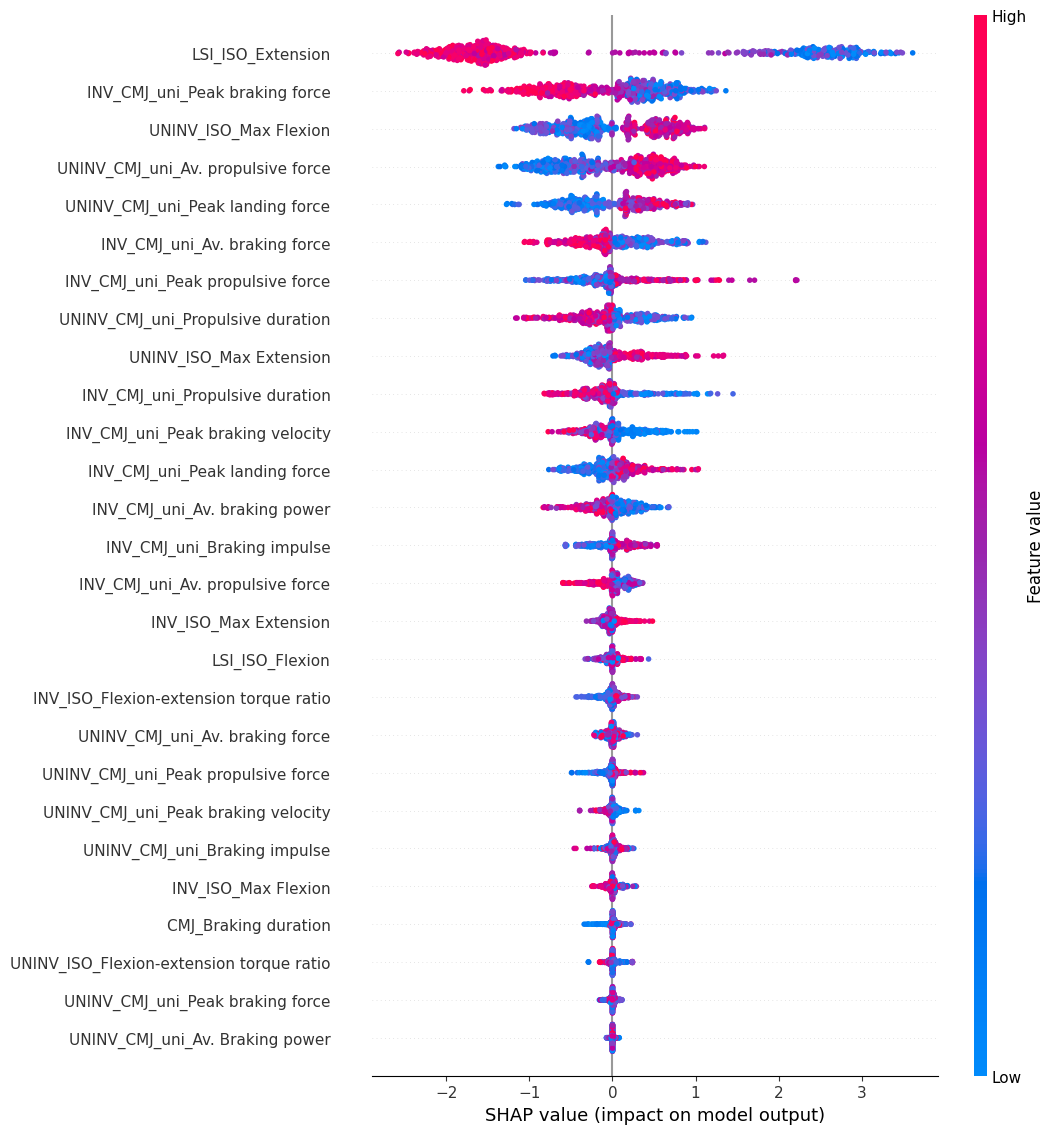

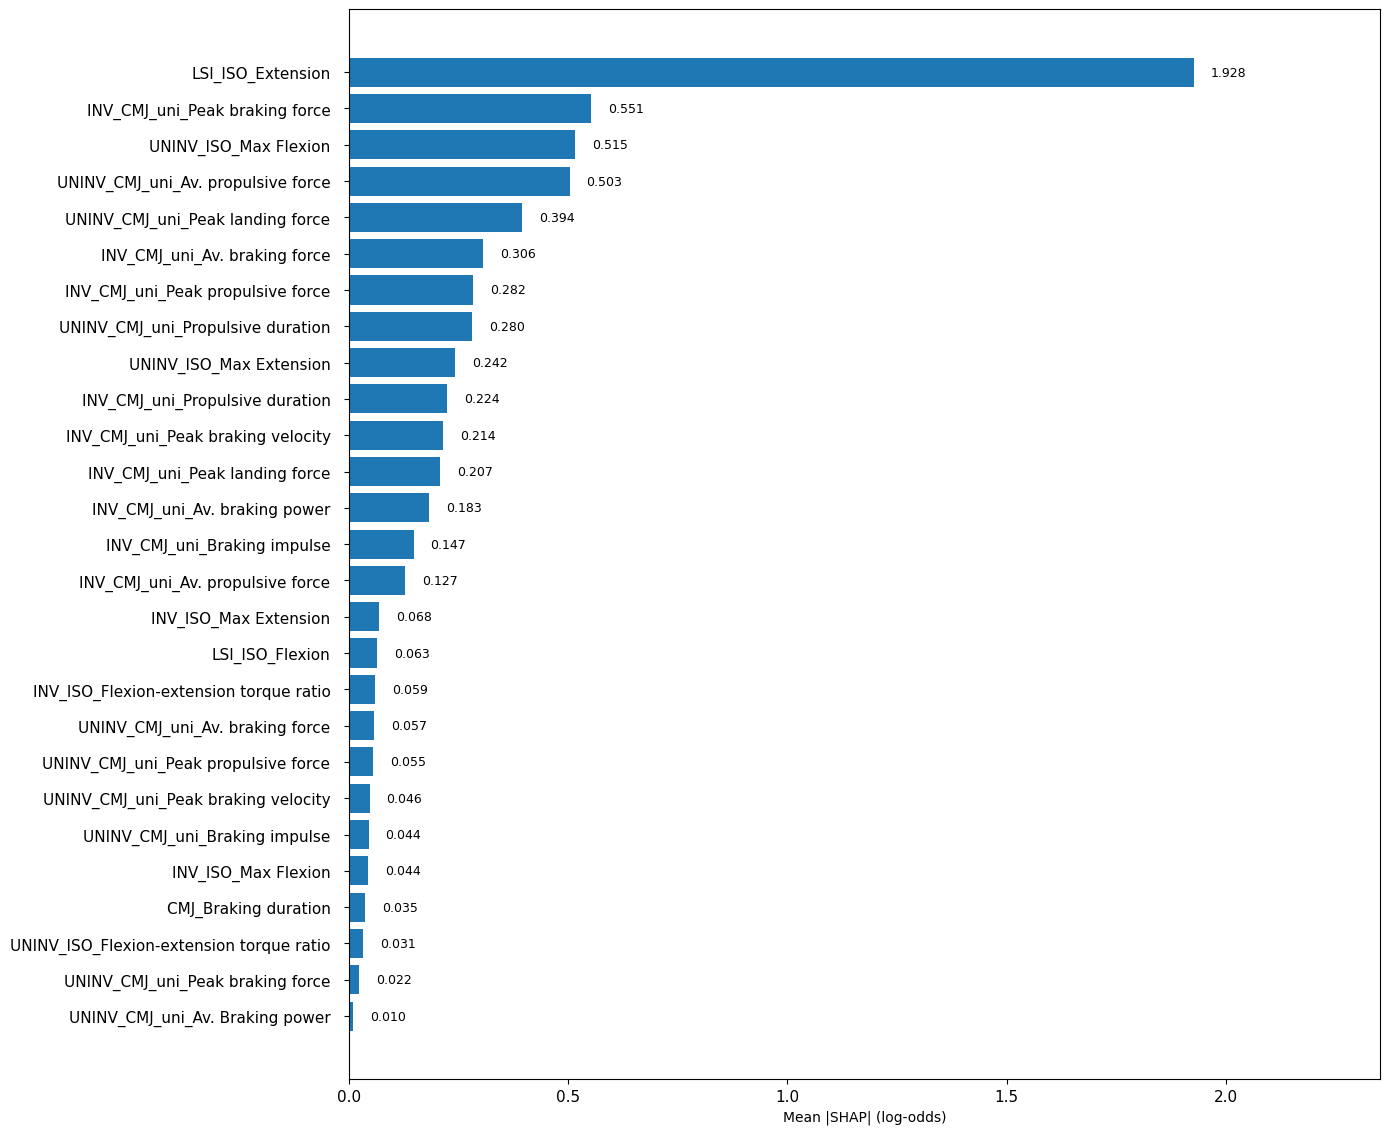

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import shap

# -----------------------------
# Parameter: Ranking-Auswahl
# -----------------------------
rank_by = "abs"   # "abs" oder "signed"
wrap_width = 40
row_height = 0.35
w = 11.0

# -----------------------------
# Reihenfolge basierend auf rank_by
# -----------------------------
if rank_by not in ("abs", "signed"):
    raise ValueError("rank_by must be 'abs' or 'signed'.")

if rank_by == "abs":
    ranking_scores = abs_mean_shaps.copy()                 # mean(|SHAP|)
else:  # rank_by == "signed"
    ranking_scores = np.abs(signed_mean_shaps).copy()      # |mean(SHAP)| für Sortierung

order_bar = np.argsort(ranking_scores)[::-1]               # absteigend                             
order_bee = order_bar                                      # Beeswarm: Top oben

# Einheitliche Höhe pro Feature
h = row_height * len(order_bee) + 2.0

# Einheitliche, weich umgebrochene Labels in identischer Reihenfolge
wrapped_names = [textwrap.fill(features[i], width=wrap_width) for i in order_bee]

# =============================
# 1) BEESWARM
# =============================
shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),
    sort=False,
    color_bar=True,
    plot_size=(w, h),
    show=False
)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()

# =============================
# 2) BALKENPLOT (zweite Grafik)
# =============================

w2 = 14.0        # Breite bei Bedarf weiter erhöhen
pad_frac = 0.22  # zusätzlicher Platz rechts/links für Labels

fig, ax = plt.subplots(figsize=(w2, h))

y = np.arange(len(order_bee))

if rank_by == "signed":
    # Anzeige: signed_mean (mit Vorzeichen), zentriert um 0
    vals = signed_mean_shaps[order_bee]
    max_abs = np.nanmax(np.abs(vals)) if vals.size else 1.0
    ax.barh(y, vals)

    # Werte-Label am Balkenende
    eps = 0.02 * max_abs
    for yi, v in zip(y, vals):
        if np.isfinite(v) and v != 0:
            ax.text(v + (eps if v > 0 else -eps), yi, f"{v:+.3f}",
                    va='center', ha=('left' if v > 0 else 'right'), fontsize=9)
        else:
            ax.text(0 + eps, yi, f"{0:+.3f}", va='center', ha='left', fontsize=9)

    # symmetrische Achse mit Extra-Puffer
    ax.set_xlim(-max_abs * (1 + pad_frac), max_abs * (1 + pad_frac))
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Mean SHAP (log-odds, signed)")

else:
    # Anzeige: mean(|SHAP|)
    vals = abs_mean_shaps[order_bee]
    vmax = np.nanmax(vals) if vals.size else 1.0
    ax.barh(y, vals)

    eps = 0.02 * vmax
    for yi, v in zip(y, vals):
        v = 0.0 if not np.isfinite(v) else v
        ax.text(v + eps, yi, f"{v:.3f}", va='center', ha='left', fontsize=9)

    ax.set_xlim(0, vmax * (1 + pad_frac))
    ax.set_xlabel("Mean |SHAP| (log-odds)")

# Y-Achse und Layout wie im Beeswarm
ax.set_yticks(y)
ax.set_yticklabels(wrapped_names)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
fig.subplots_adjust(left=0.35, right=0.985, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()




### TOP 10 abs SHAP

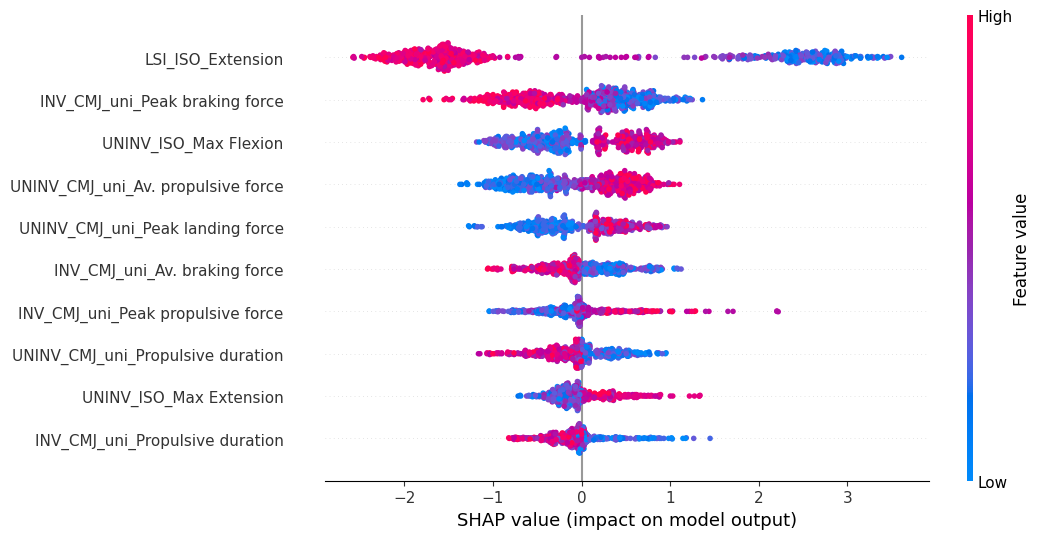

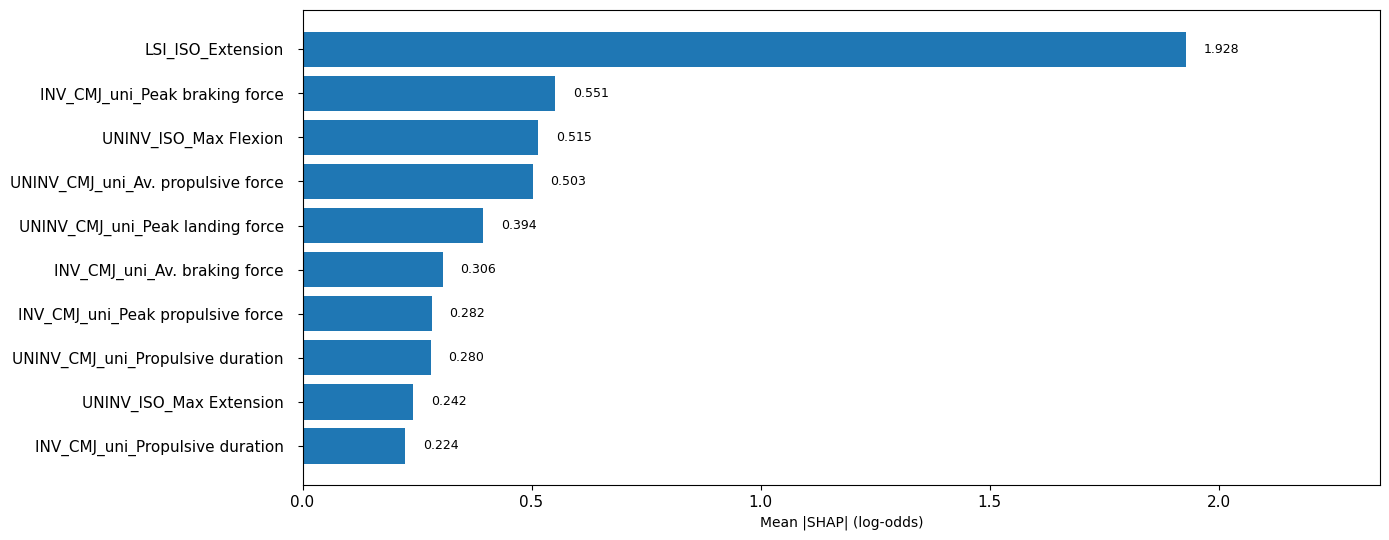

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import shap

# -----------------------------
# Parameter: Ranking-Auswahl
# -----------------------------
rank_by = "abs"   # "abs" oder "signed"
TOP_K = 10 
wrap_width = 40
row_height = 0.35
w = 11.0

# -----------------------------
# Reihenfolge basierend auf rank_by
# -----------------------------
if rank_by not in ("abs", "signed"):
    raise ValueError("rank_by must be 'abs' or 'signed'.")

if rank_by == "abs":
    ranking_scores = abs_mean_shaps.copy()                 # mean(|SHAP|)
else:  # rank_by == "signed"
    ranking_scores = np.abs(signed_mean_shaps).copy()      # |mean(SHAP)| für Sortierung

order_bar_full = np.argsort(ranking_scores)[::-1]          # absteigend
top_k = min(TOP_K, len(order_bar_full))                    # falls <10 Features
order_bee = order_bar_full[:top_k]                         # << nur Top K
order_bar = order_bee                                      # identisch verwenden

# Höhe an Top K anpassen
h = row_height * len(order_bee) + 2.0

# Einheitliche, weich umgebrochene Labels (Top K)
wrapped_names = [textwrap.fill(features[i], width=wrap_width) for i in order_bee]

# =============================
# 1) BEESWARM
# =============================
shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),   # << sicherheitshalber
    sort=False,
    color_bar=True,
    plot_size=(w, h),
    show=False
)
ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()

# =============================
# 2) BALKENPLOT (zweite Grafik)
# =============================

w2 = 14.0        # Breite bei Bedarf weiter erhöhen
pad_frac = 0.22  # zusätzlicher Platz rechts/links für Labels

fig, ax = plt.subplots(figsize=(w2, h))

y = np.arange(len(order_bee))

if rank_by == "signed":
    # Anzeige: signed_mean (mit Vorzeichen), zentriert um 0
    vals = signed_mean_shaps[order_bee]
    max_abs = np.nanmax(np.abs(vals)) if vals.size else 1.0
    ax.barh(y, vals)

    # Werte-Label am Balkenende
    eps = 0.02 * max_abs
    for yi, v in zip(y, vals):
        if np.isfinite(v) and v != 0:
            ax.text(v + (eps if v > 0 else -eps), yi, f"{v:+.3f}",
                    va='center', ha=('left' if v > 0 else 'right'), fontsize=9)
        else:
            ax.text(0 + eps, yi, f"{0:+.3f}", va='center', ha='left', fontsize=9)

    # symmetrische Achse mit Extra-Puffer
    ax.set_xlim(-max_abs * (1 + pad_frac), max_abs * (1 + pad_frac))
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Mean SHAP (log-odds, signed)")

else:
    # Anzeige: mean(|SHAP|)
    vals = abs_mean_shaps[order_bee]
    vmax = np.nanmax(vals) if vals.size else 1.0
    ax.barh(y, vals)

    eps = 0.02 * vmax
    for yi, v in zip(y, vals):
        v = 0.0 if not np.isfinite(v) else v
        ax.text(v + eps, yi, f"{v:.3f}", va='center', ha='left', fontsize=9)

    ax.set_xlim(0, vmax * (1 + pad_frac))
    ax.set_xlabel("Mean |SHAP| (log-odds)")

# Y-Achse und Layout wie im Beeswarm
ax.set_yticks(y)
ax.set_yticklabels(wrapped_names)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
fig.subplots_adjust(left=0.35, right=0.985, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()




### signed SHAP

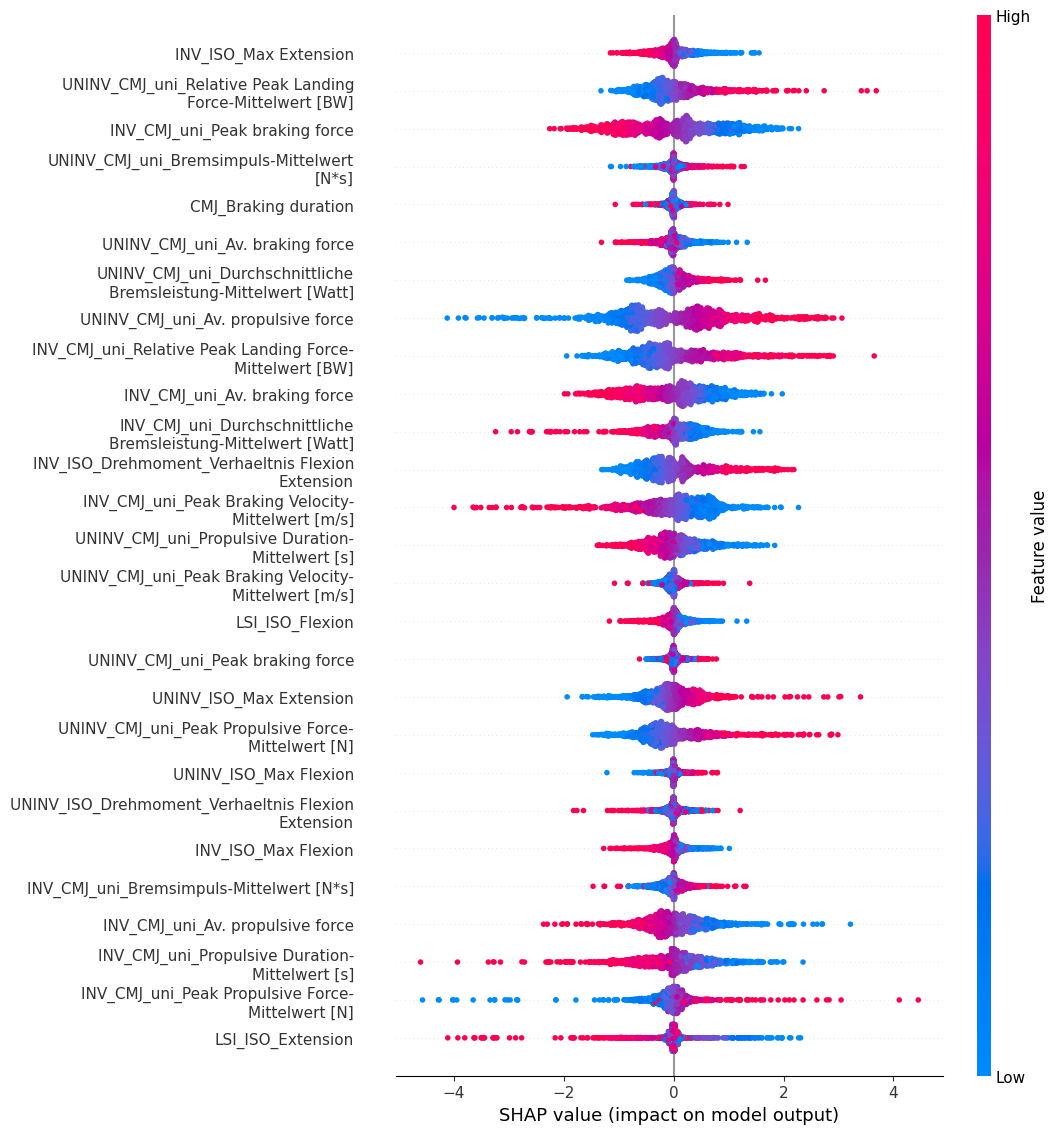

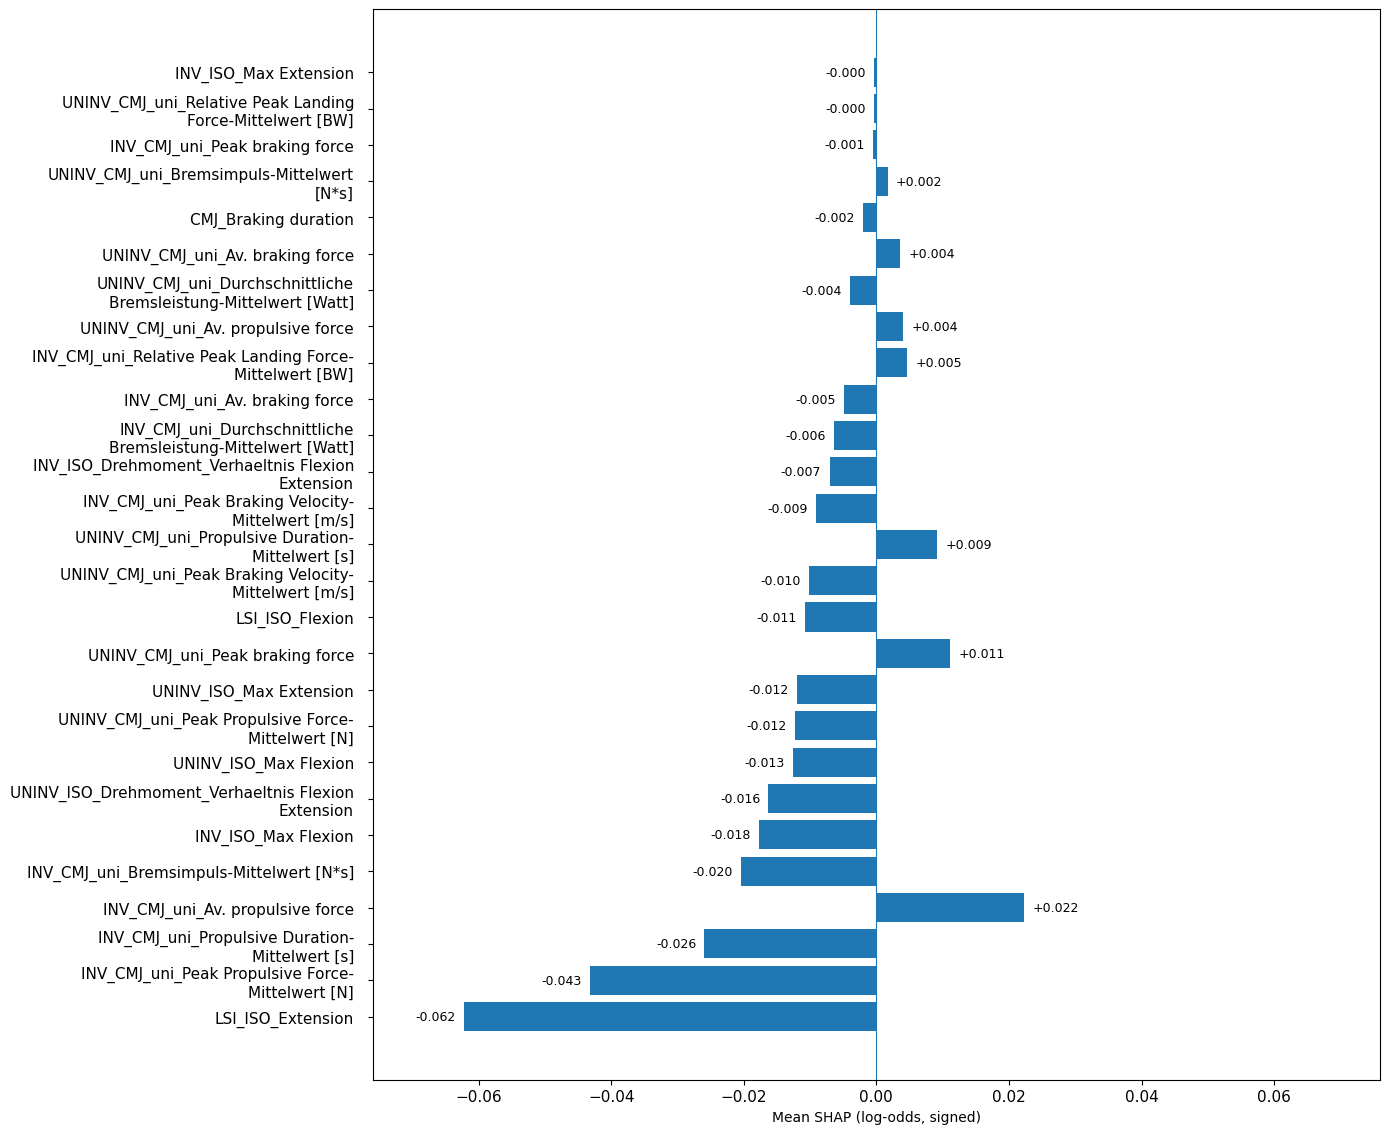

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import shap

# -----------------------------
# Parameter: Ranking-Auswahl
# -----------------------------
rank_by = "signed"   # "abs" oder "signed"
wrap_width = 40
row_height = 0.35
w = 11.0

# -----------------------------
# Reihenfolge basierend auf rank_by
# -----------------------------
if rank_by not in ("abs", "signed"):
    raise ValueError("rank_by must be 'abs' or 'signed'.")

if rank_by == "abs":
    ranking_scores = abs_mean_shaps.copy()                 # mean(|SHAP|)
else:  # rank_by == "signed"
    ranking_scores = np.abs(signed_mean_shaps).copy()      # |mean(SHAP)| für Sortierung

order_bar = np.argsort(ranking_scores)[::-1]               # absteigend
order_bee = order_bar[::-1]                                # Beeswarm: Top oben

# Einheitliche Höhe pro Feature
h = row_height * len(order_bee) + 2.0

# Einheitliche, weich umgebrochene Labels in identischer Reihenfolge
wrapped_names = [textwrap.fill(features[i], width=wrap_width) for i in order_bee]

# =============================
# 1) BEESWARM (wie bei dir)
# =============================
shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),
    sort=False,
    color_bar=True,
    plot_size=(w, h),
    show=False
)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()

# =============================
# 2) BALKENPLOT (zweite Grafik)
# =============================

w2 = 14.0        # breiter als w (=11.0); bei Bedarf weiter erhöhen
pad_frac = 0.22  # zusätzlicher Platz (22 %) rechts/links für Labels

fig, ax = plt.subplots(figsize=(w2, h))

y = np.arange(len(order_bee))

if rank_by == "signed":
    # Anzeige: signed_mean (mit Vorzeichen), zentriert um 0
    vals = signed_mean_shaps[order_bee]
    max_abs = np.nanmax(np.abs(vals)) if vals.size else 1.0
    ax.barh(y, vals)

    # Werte-Label am Balkenende
    eps = 0.02 * max_abs
    for yi, v in zip(y, vals):
        if np.isfinite(v) and v != 0:
            ax.text(v + (eps if v > 0 else -eps), yi, f"{v:+.3f}",
                    va='center', ha=('left' if v > 0 else 'right'), fontsize=9)
        else:
            ax.text(0 + eps, yi, f"{0:+.3f}", va='center', ha='left', fontsize=9)

    # symmetrische Achse mit Extra-Puffer
    ax.set_xlim(-max_abs * (1 + pad_frac), max_abs * (1 + pad_frac))
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Mean SHAP (log-odds, signed)")

else:
    # Anzeige: mean(|SHAP|)
    vals = abs_mean_shaps[order_bee]
    vmax = np.nanmax(vals) if vals.size else 1.0
    ax.barh(y, vals)

    eps = 0.02 * vmax
    for yi, v in zip(y, vals):
        v = 0.0 if not np.isfinite(v) else v
        ax.text(v + eps, yi, f"{v:.3f}", va='center', ha='left', fontsize=9)

    ax.set_xlim(0, vmax * (1 + pad_frac))
    ax.set_xlabel("Mean |SHAP| (log-odds)")

# Y-Achse und Layout wie im Beeswarm
ax.set_yticks(y)
ax.set_yticklabels(wrapped_names)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
fig.subplots_adjust(left=0.35, right=0.985, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()




### Maestroni Daten und Beeswarm/Bar Plot

### abs SHAP

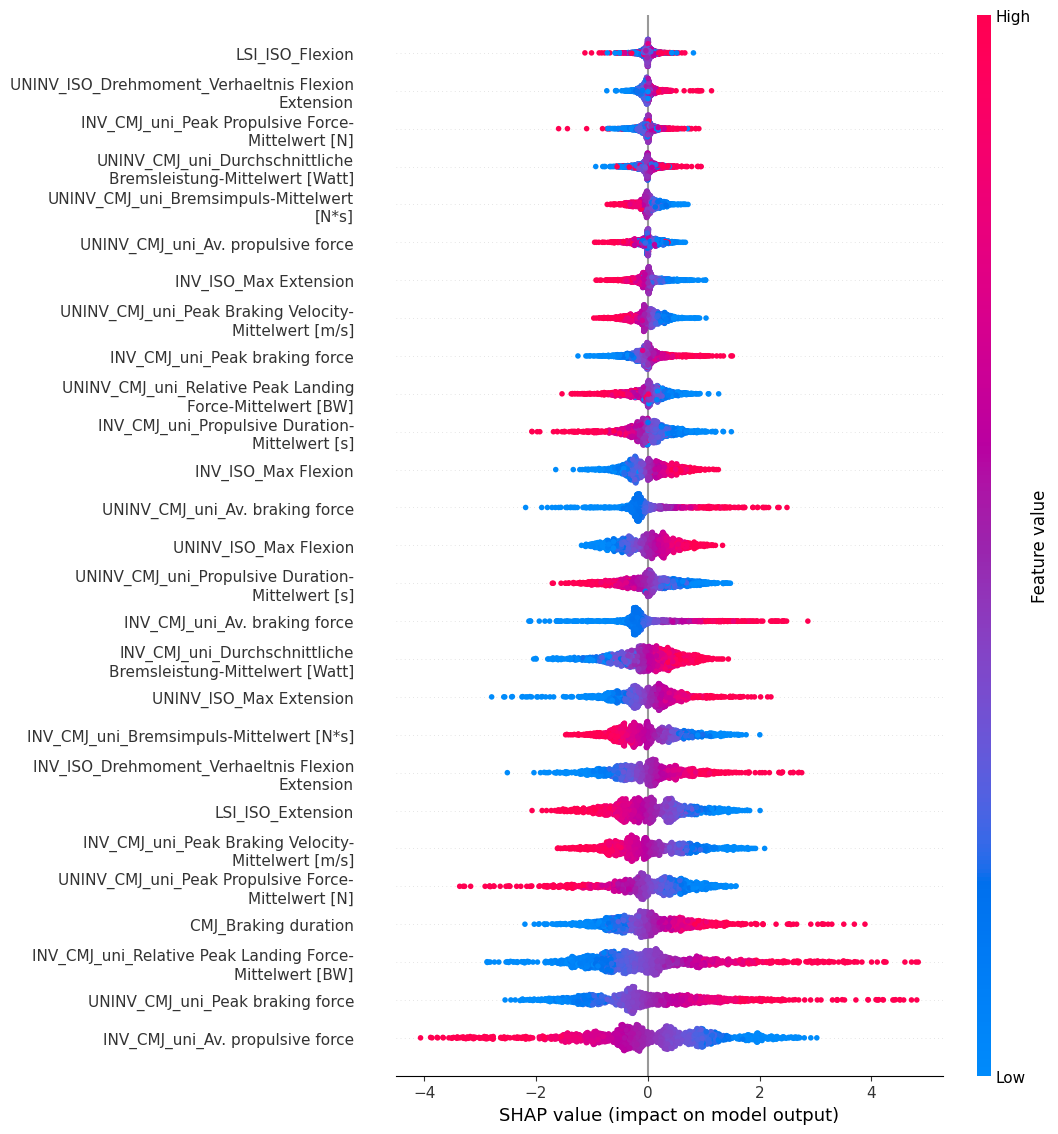

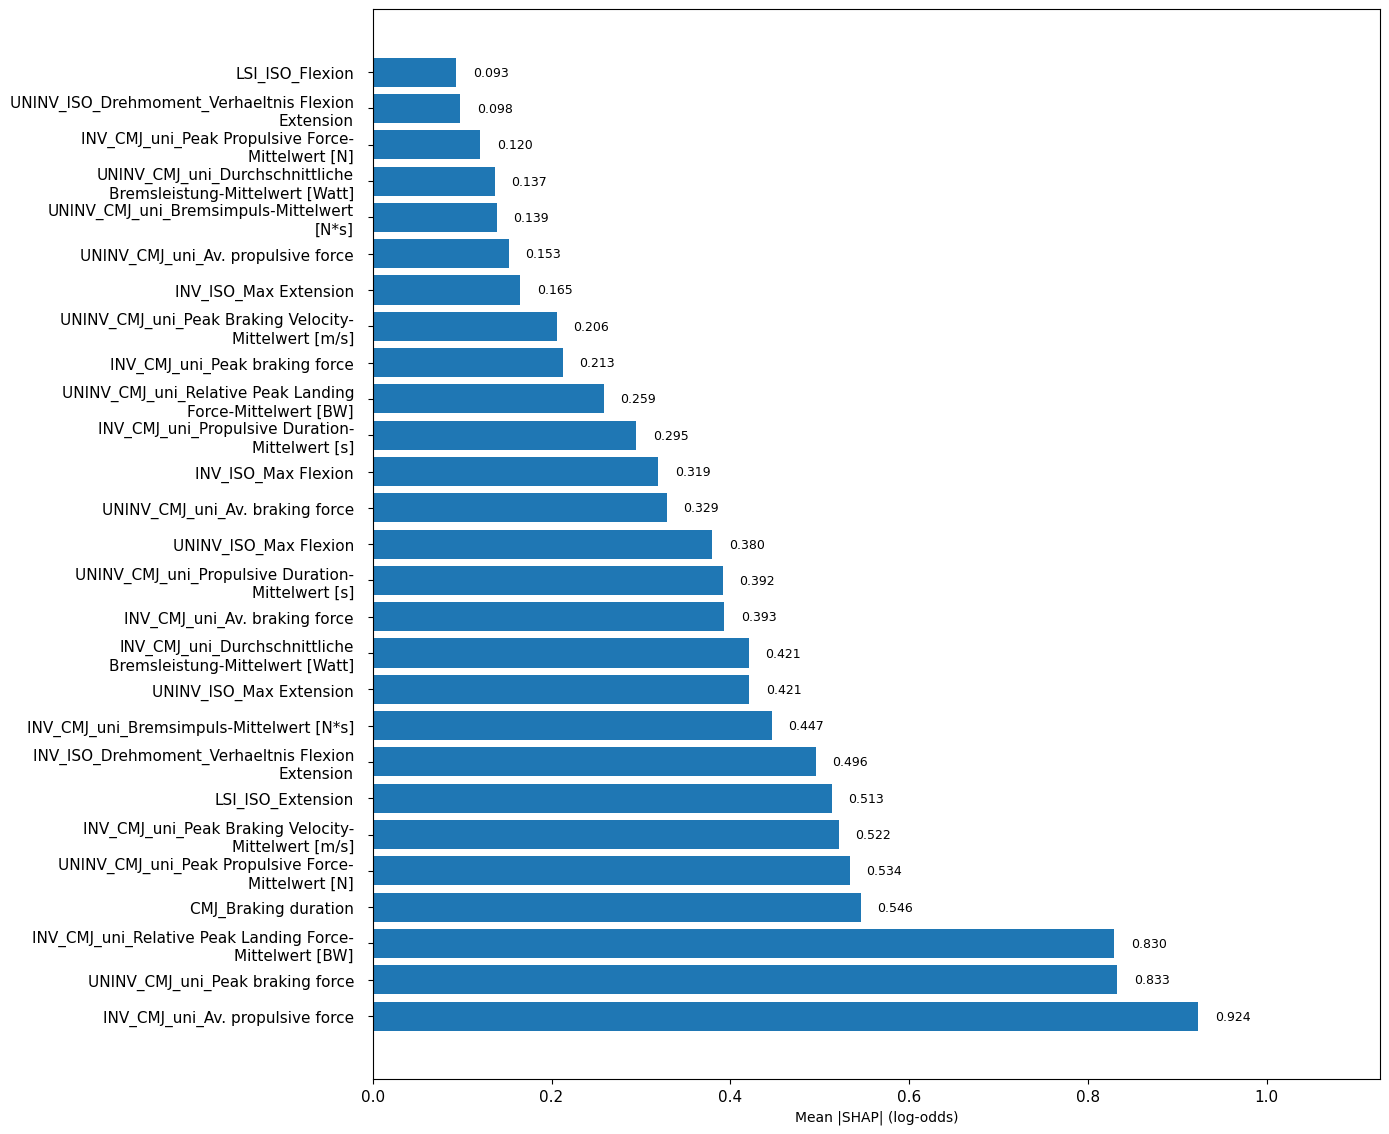

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import shap

# -----------------------------
# Parameter: Ranking-Auswahl
# -----------------------------
rank_by = "abs"   # "abs" oder "signed"
wrap_width = 40
row_height = 0.35
w = 11.0

# -----------------------------
# Reihenfolge basierend auf rank_by
# -----------------------------
if rank_by not in ("abs", "signed"):
    raise ValueError("rank_by must be 'abs' or 'signed'.")

if rank_by == "abs":
    ranking_scores = abs_mean_shaps.copy()                 # mean(|SHAP|)
else:  # rank_by == "signed"
    ranking_scores = np.abs(signed_mean_shaps).copy()      # |mean(SHAP)| für Sortierung

order_bar = np.argsort(ranking_scores)[::-1]               # absteigend
order_bee = order_bar[::-1]                                # Beeswarm: Top oben

# Einheitliche Höhe pro Feature
h = row_height * len(order_bee) + 2.0

# Einheitliche, weich umgebrochene Labels in identischer Reihenfolge
wrapped_names = [textwrap.fill(features[i], width=wrap_width) for i in order_bee]

# =============================
# 1) BEESWARM (wie bei dir)
# =============================
shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),
    sort=False,
    color_bar=True,
    plot_size=(w, h),
    show=False
)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()

# =============================
# 2) BALKENPLOT (zweite Grafik)
# =============================

w2 = 14.0        # breiter als w (=11.0); bei Bedarf weiter erhöhen
pad_frac = 0.22  # zusätzlicher Platz (22 %) rechts/links für Labels

fig, ax = plt.subplots(figsize=(w2, h))

y = np.arange(len(order_bee))

if rank_by == "signed":
    # Anzeige: signed_mean (mit Vorzeichen), zentriert um 0
    vals = signed_mean_shaps[order_bee]
    max_abs = np.nanmax(np.abs(vals)) if vals.size else 1.0
    ax.barh(y, vals)

    # Werte-Label am Balkenende
    eps = 0.02 * max_abs
    for yi, v in zip(y, vals):
        if np.isfinite(v) and v != 0:
            ax.text(v + (eps if v > 0 else -eps), yi, f"{v:+.3f}",
                    va='center', ha=('left' if v > 0 else 'right'), fontsize=9)
        else:
            ax.text(0 + eps, yi, f"{0:+.3f}", va='center', ha='left', fontsize=9)

    # symmetrische Achse mit Extra-Puffer
    ax.set_xlim(-max_abs * (1 + pad_frac), max_abs * (1 + pad_frac))
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Mean SHAP (log-odds, signed)")

else:
    # Anzeige: mean(|SHAP|)
    vals = abs_mean_shaps[order_bee]
    vmax = np.nanmax(vals) if vals.size else 1.0
    ax.barh(y, vals)

    eps = 0.02 * vmax
    for yi, v in zip(y, vals):
        v = 0.0 if not np.isfinite(v) else v
        ax.text(v + eps, yi, f"{v:.3f}", va='center', ha='left', fontsize=9)

    ax.set_xlim(0, vmax * (1 + pad_frac))
    ax.set_xlabel("Mean |SHAP| (log-odds)")

# Y-Achse und Layout wie im Beeswarm
ax.set_yticks(y)
ax.set_yticklabels(wrapped_names)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
fig.subplots_adjust(left=0.35, right=0.985, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()




### signed SHAP

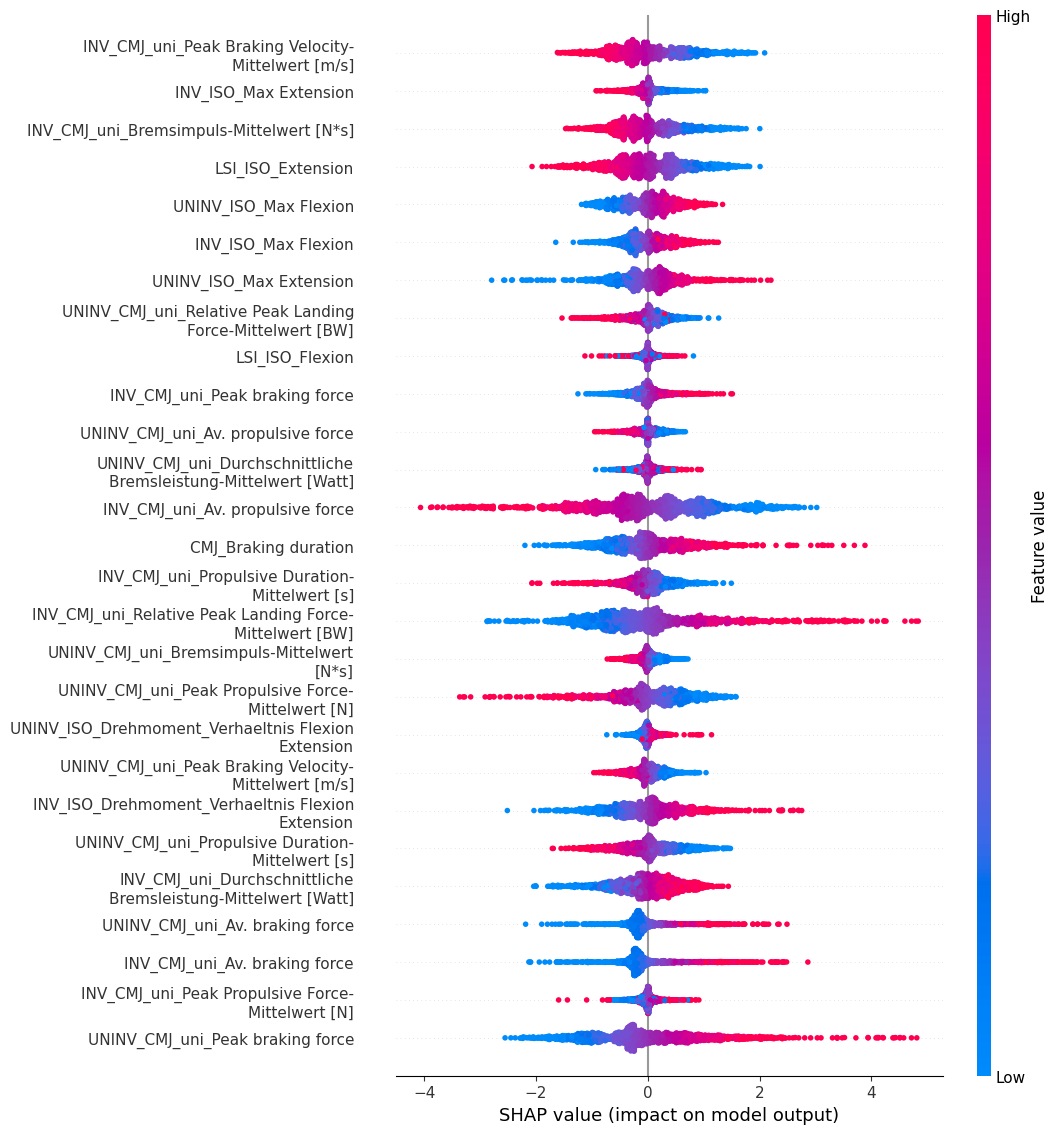

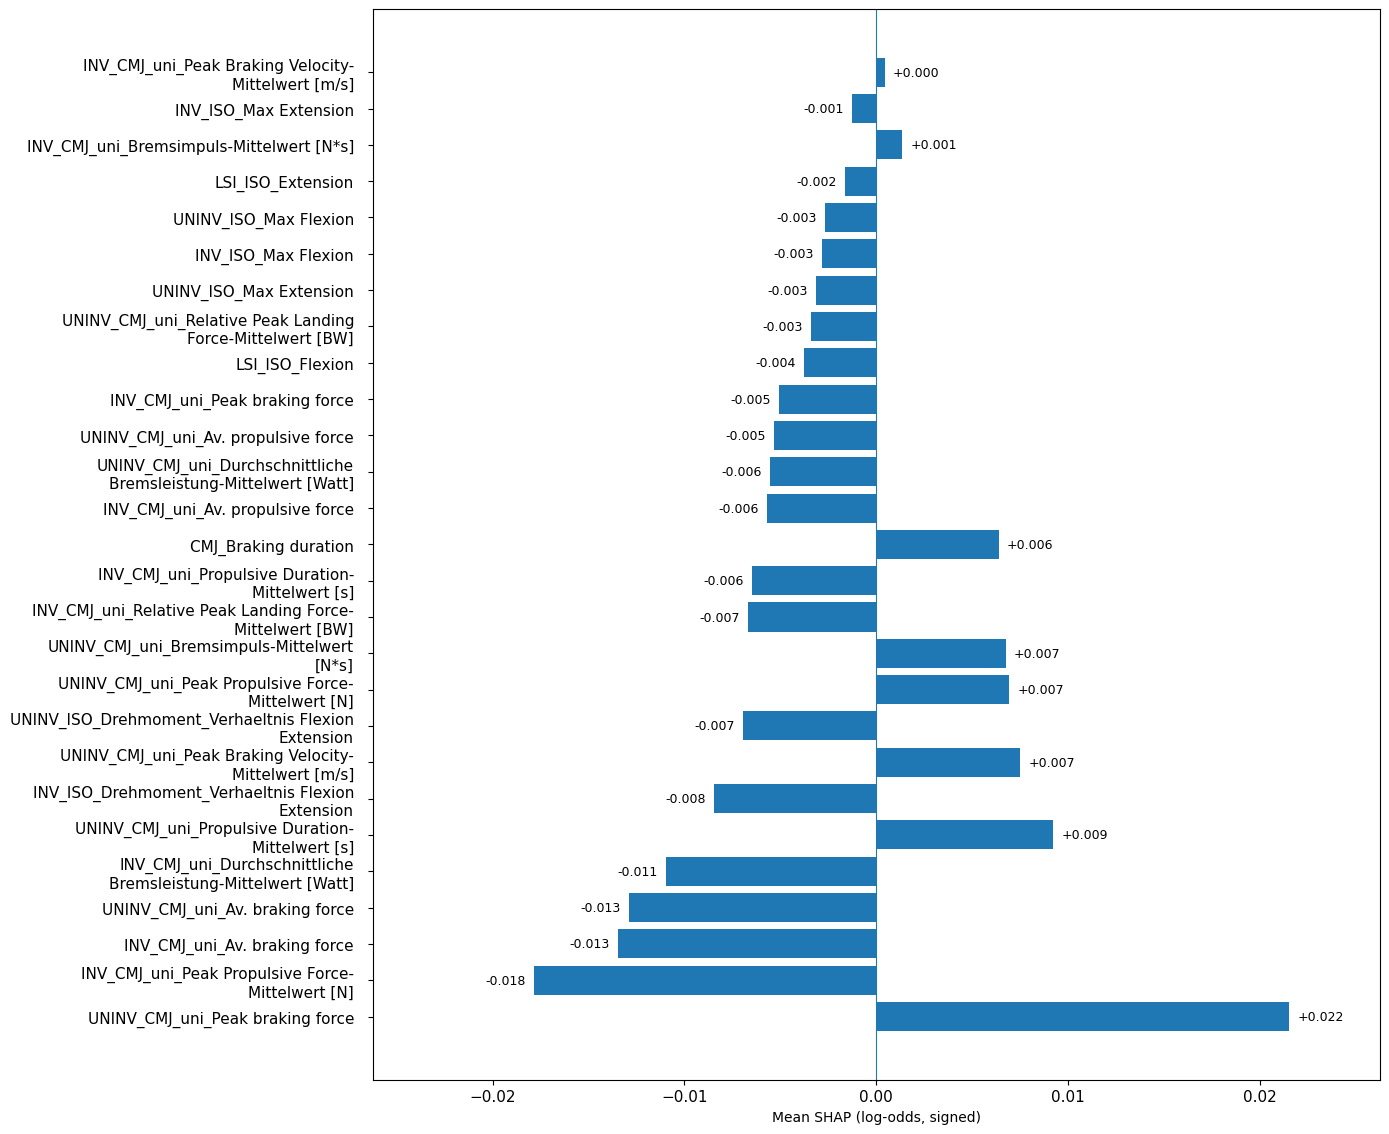

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import shap

# -----------------------------
# Parameter: Ranking-Auswahl
# -----------------------------
rank_by = "signed"   # "abs" oder "signed"
wrap_width = 40
row_height = 0.35
w = 11.0

# -----------------------------
# Reihenfolge basierend auf rank_by
# -----------------------------
if rank_by not in ("abs", "signed"):
    raise ValueError("rank_by must be 'abs' or 'signed'.")

if rank_by == "abs":
    ranking_scores = abs_mean_shaps.copy()                 # mean(|SHAP|)
else:  # rank_by == "signed"
    ranking_scores = np.abs(signed_mean_shaps).copy()      # |mean(SHAP)| für Sortierung

order_bar = np.argsort(ranking_scores)[::-1]               # absteigend
order_bee = order_bar[::-1]                                # Beeswarm: Top oben

# Einheitliche Höhe pro Feature
h = row_height * len(order_bee) + 2.0

# Einheitliche, weich umgebrochene Labels in identischer Reihenfolge
wrapped_names = [textwrap.fill(features[i], width=wrap_width) for i in order_bee]

# =============================
# 1) BEESWARM (wie bei dir)
# =============================
shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),
    sort=False,
    color_bar=True,
    plot_size=(w, h),
    show=False
)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()

# =============================
# 2) BALKENPLOT (zweite Grafik)
# =============================

w2 = 14.0        # breiter als w (=11.0); bei Bedarf weiter erhöhen
pad_frac = 0.22  # zusätzlicher Platz (22 %) rechts/links für Labels

fig, ax = plt.subplots(figsize=(w2, h))

y = np.arange(len(order_bee))

if rank_by == "signed":
    # Anzeige: signed_mean (mit Vorzeichen), zentriert um 0
    vals = signed_mean_shaps[order_bee]
    max_abs = np.nanmax(np.abs(vals)) if vals.size else 1.0
    ax.barh(y, vals)

    # Werte-Label am Balkenende
    eps = 0.02 * max_abs
    for yi, v in zip(y, vals):
        if np.isfinite(v) and v != 0:
            ax.text(v + (eps if v > 0 else -eps), yi, f"{v:+.3f}",
                    va='center', ha=('left' if v > 0 else 'right'), fontsize=9)
        else:
            ax.text(0 + eps, yi, f"{0:+.3f}", va='center', ha='left', fontsize=9)

    # symmetrische Achse mit Extra-Puffer
    ax.set_xlim(-max_abs * (1 + pad_frac), max_abs * (1 + pad_frac))
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Mean SHAP (log-odds, signed)")

else:
    # Anzeige: mean(|SHAP|)
    vals = abs_mean_shaps[order_bee]
    vmax = np.nanmax(vals) if vals.size else 1.0
    ax.barh(y, vals)

    eps = 0.02 * vmax
    for yi, v in zip(y, vals):
        v = 0.0 if not np.isfinite(v) else v
        ax.text(v + eps, yi, f"{v:.3f}", va='center', ha='left', fontsize=9)

    ax.set_xlim(0, vmax * (1 + pad_frac))
    ax.set_xlabel("Mean |SHAP| (log-odds)")

# Y-Achse und Layout wie im Beeswarm
ax.set_yticks(y)
ax.set_yticklabels(wrapped_names)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
fig.subplots_adjust(left=0.35, right=0.985, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()




### Tabelle mit SHAP-Werten und Stabilitätsmetriken

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False,
    subject_id_column=None  # optional: echte ID-Spalte; None ⇒ df.index als ID
):
    """
    Trainiert LR mit CV, sammelt SHAP (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (Wichtigkeit)
      - subject_ids_stack: (N_ooF,) ID je Zeile (Index-Fallback, wenn keine ID-Spalte)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    if target_column not in df.columns:
        raise ValueError(f"target_column '{target_column}' not found in data.")
    y = df[target_column].astype(int)

    # ID-Quelle definieren (Index als Fallback)
    if subject_id_column is None:
        sid_values = df.index.to_numpy()
        drop_cols = [target_column]
    else:
        if subject_id_column not in df.columns:
            raise ValueError(f"subject_id_column '{subject_id_column}' not found in data.")
        sid_values = df[subject_id_column].to_numpy()
        drop_cols = [target_column, subject_id_column]

    # Feature-Matrix (ID & Target raus)
    X = df.drop(columns=drop_cols, errors="ignore")
    features = X.columns.tolist()
    if len(features) == 0:
        raise ValueError("No features left after dropping target/ID columns.")

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap, all_X, all_ids = [], [], []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None),
            n_jobs=None
        )
        lr.fit(X_train_s, y_train)

        last_model    = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # IDs der Testfälle (gleiche Reihenfolge wie SHAP) sammeln
        test_ids = sid_values[test_idx]
        all_ids.append(test_ids)

        # expected_value für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)       # [N_total, n_features]
    X_stack    = np.vstack(all_X)          # [N_total, n_features]
    subject_ids_stack = np.concatenate(all_ids)  # [N_total,]

    # 7) Kennzahlen (global)
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps,
        subject_ids_stack
    )

# ========= Aufruf =========
DATA_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Motum_ML.xlsx"
(features, shap_stack, X_stack, exp_val, last_model, last_test_len,
 signed_mean_shaps, abs_mean_shaps, subject_ids_stack) = collect_shap_data_lr(
    data_path            = DATA_PATH,
    target_column        = "Verletzungsstatus",
    cv_splits            = 5,
    cv_repeats           = 20,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False,
    subject_id_column    = None  # None ⇒ df.index als ID
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())




SHAP-Wertprüfung:
→ Min: -4.601785791104535 Max: 4.450765755077146 Mean: -0.008208019231255208
→ Anzahl NaN: 0 Inf: 0


### Maestroni-Daten

In [17]:
import numpy as np
import pandas as pd

def _aggregate_subject_level(shap_stack, subject_ids):
    """
    Mittelt SHAPs je Subjekt (hier: Zeilenindex-Cluster) → (S × p) Matrix.
    subject_ids: (N_ooF,) gleiche Reihenfolge wie shap_stack.
    """
    df = pd.DataFrame(shap_stack)
    df["__sid__"] = subject_ids
    subj_means = df.groupby("__sid__", sort=False).mean()
    subj_ids = subj_means.index.to_numpy()
    subj_means = subj_means.drop(columns=[], errors="ignore")  # no-op
    return subj_means.values, subj_ids  # (S × p), (S,)

def _feature_metrics(subject_level_phi):
    """
    subject_level_phi: (S × p) SHAP-Matrix nach Subjekt-Mittelung.
    Liefert je Feature:
      - abs_mean = mean(|phi|)
      - signed_mean = mean(phi)
      - p_pos = Anteil(phi>0)
      - FI = 2*min(p_pos, 1-p_pos)
      - RK = |mean(phi)| / mean(|phi|)
    """
    S, p = subject_level_phi.shape
    abs_mean     = np.nanmean(np.abs(subject_level_phi), axis=0)
    signed_mean  = np.nanmean(subject_level_phi, axis=0)
    p_pos        = np.nanmean((subject_level_phi > 0).astype(float), axis=0)
    fi           = 2.0 * np.minimum(p_pos, 1.0 - p_pos)
    eps          = 1e-12
    rk           = np.abs(signed_mean) / np.maximum(abs_mean, eps)
    return abs_mean, signed_mean, p_pos, fi, rk

def shap_table_with_boot_ci(
    shap_stack, subject_ids_stack, features,
    B=2000, alpha=0.05, random_state=42
):
    """
    Baut eine Tabelle pro Feature mit Punktwerten + 95%-KI:
      - mean(|SHAP|), signed mean, p_pos, FI, RK
    Sortiert nach mean(|SHAP|) absteigend.
    Bootstrap: Cluster-Bootstrap über Subjekte (resample IDs).
    """
    if subject_ids_stack is None:
        raise ValueError("subject_ids_stack ist None. Bitte collect_shap_data_lr mit Index/ID nutzen.")

    rng = np.random.default_rng(random_state)

    # 1) Subjekt-Ebene aggregieren
    subj_phi, subj_ids = _aggregate_subject_level(shap_stack, subject_ids_stack)  # (S × p)

    # 2) Punkt-Schätzer
    abs_mean_pt, signed_mean_pt, p_pos_pt, fi_pt, rk_pt = _feature_metrics(subj_phi)

    # 3) Bootstrap (Cluster über Subjekte)
    S, p = subj_phi.shape
    B = int(B)
    abs_mean_bs = np.empty((B, p))
    signed_bs   = np.empty((B, p))
    ppos_bs     = np.empty((B, p))
    fi_bs       = np.empty((B, p))
    rk_bs       = np.empty((B, p))

    for b in range(B):
        boot_idx = rng.integers(0, S, size=S)   # resample Subjekte
        boot_phi = subj_phi[boot_idx, :]
        am, sm, pp, fi, rk = _feature_metrics(boot_phi)
        abs_mean_bs[b, :], signed_bs[b, :], ppos_bs[b, :], fi_bs[b, :], rk_bs[b, :] = am, sm, pp, fi, rk

    lo, hi = 100*alpha/2, 100*(1-alpha/2)
    def ci(arr):  # arr: (B × p)
        return (np.nanpercentile(arr, lo, axis=0),
                np.nanpercentile(arr, hi, axis=0))

    abs_lo, abs_hi = ci(abs_mean_bs)
    sm_lo,  sm_hi  = ci(signed_bs)
    pp_lo,  pp_hi  = ci(ppos_bs)
    fi_lo,  fi_hi  = ci(fi_bs)
    rk_lo,  rk_hi  = ci(rk_bs)

    # 4) Numerische Tabelle bauen & sortieren (Rohwerte + KI-Rohspalten)
    df_out = pd.DataFrame({
        "Feature": features,
        "mean|SHAP|": abs_mean_pt,
        "mean|SHAP|_lo": abs_lo,
        "mean|SHAP|_hi": abs_hi,
        "signed_mean": signed_mean_pt,
        "signed_lo": sm_lo,
        "signed_hi": sm_hi,
        "p_pos": p_pos_pt,
        "p_pos_lo": pp_lo,
        "p_pos_hi": pp_hi,
        "FI": fi_pt,
        "FI_lo": fi_lo,
        "FI_hi": fi_hi,
        "RK": rk_pt,
        "RK_lo": rk_lo,
        "RK_hi": rk_hi,
    }).sort_values("mean|SHAP|", ascending=False).reset_index(drop=True)

    return df_out

# ------------------ Anzeige/Formatting: KI direkt neben Wert ------------------

def _fmt_ci(lo, hi, decimals=3, as_percent=False):
    if as_percent:
        if np.isnan(lo) or np.isnan(hi):
            return "(NA–NA)"
        return f"({lo*100:.{decimals}f}–{hi*100:.{decimals}f} %)"
    else:
        if np.isnan(lo) or np.isnan(hi):
            return "(NA–NA)"
        return f"({lo:.{decimals}f}–{hi:.{decimals}f})"

def format_shap_table_for_display(
    df_numeric: pd.DataFrame,
    decimals_main=3,
    as_percent_for=("p_pos", "FI"),  # diese Metriken optional als % zeigen
):
    """
    Nimmt die numerische df (mit *_lo/_hi) und erzeugt eine Display-Tabelle,
    in der jede Metrik direkt eine KI-Spalte daneben hat.
    """
    # Kopie, damit Original erhalten bleibt
    dfn = df_numeric.copy()

    # Optional: numerische Wertespalten runden für die Anzeige
    def _round_series(s, as_percent=False):
        if as_percent:
            return (s * 100).round(decimals_main)
        return s.round(decimals_main)

    # Metriken-Definitionen (Name, lo, hi, als Prozent?)
    specs = [
        ("mean|SHAP|",  "mean|SHAP|_lo", "mean|SHAP|_hi", False),
        ("signed_mean", "signed_lo",     "signed_hi",     False),
        ("p_pos",       "p_pos_lo",      "p_pos_hi",      "p_pos" in as_percent_for),
        ("FI",          "FI_lo",         "FI_hi",         "FI" in as_percent_for),
        ("RK",          "RK_lo",         "RK_hi",         False),
    ]

    # Display-Spalten bauen
    disp_cols = ["Feature"]
    disp_data = {"Feature": dfn["Feature"]}

    for name, lo_name, hi_name, as_pct in specs:
        # Wert
        val_col = name
        val_series = _round_series(dfn[val_col], as_percent=as_pct)
        # KI
        ci_col = f"{name} KI"
        ci_series = [
            _fmt_ci(dfn[lo_name].iloc[i], dfn[hi_name].iloc[i],
                    decimals=decimals_main, as_percent=as_pct)
            for i in range(len(dfn))
        ]
        disp_data[val_col] = val_series
        disp_data[ci_col] = ci_series
        disp_cols.extend([val_col, ci_col])

    df_display = pd.DataFrame(disp_data, columns=disp_cols)

    return df_display

# ========= Ausführen: Tabelle berechnen & schön anzeigen =========
df_shap_numeric = shap_table_with_boot_ci(
    shap_stack=shap_stack,
    subject_ids_stack=subject_ids_stack,  # aus Zelle 1
    features=features,
    B=2000,           # für schnelle Tests ggf. 500
    alpha=0.05,
    random_state=42
)

df_shap_display = format_shap_table_for_display(
    df_shap_numeric,
    decimals_main=3,
    as_percent_for=("p_pos", "FI")  # p_pos & FI als Prozente; entferne, wenn du Dezimal willst
)

# Anzeige (Jupyter) oder Fallback auf print
try:
    display(df_shap_display)
except NameError:
    print(df_shap_display.to_string(index=False))

# ------- Legende unter der Tabelle ausgeben (ohne KI-Spalten erklären) -------
legend = """
Erklärung der Metriken (SHAP in Log-Odds):

- mean|SHAP|: mittlere absolute SHAP-Werte (globale Wichtigkeit, richtungsunabhängig).
- signed_mean: mittlerer gerichteter SHAP (kann sich bei gemischten Vorzeichen wegmitteln).
- p_pos: Anteil der (subjekt-aggregierten) Fälle mit SHAP > 0 (Richtung Klasse 1); hier als Prozent ausgegeben.
- FI: Flip-Index = 2*min(p_pos, 1-p_pos); 0 ≈ kaum Flippen, 1 ≈ starkes Flippen (hier als Prozent).
- RK: Richtungs-Kohärenz = |signed_mean| / mean|SHAP| ∈ [0,1]; nahe 1 = Richtung konsistent, nahe 0 = heterogen.

Hinweis: KIs sind 95%-Konfidenzintervalle via Cluster-Bootstrap (Resampling auf Subjektebene).
"""
print(legend)


,Feature,mean|SHAP|,mean|SHAP| KI,signed_mean,signed_mean KI,p_pos,p_pos KI,FI,FI KI,RK,RK KI
0,INV_CMJ_uni_Av. propulsive force,0.923,(0.756–1.113),-0.006,(-0.270–0.268),48.000,(37.333–58.667 %),96.000,(74.667–98.667 %),0.006,(0.005–0.332)
1,UNINV_CMJ_uni_Peak braking force,0.832,(0.681–1.001),0.022,(-0.217–0.280),44.000,(33.300–56.000 %),88.000,(66.600–98.667 %),0.026,(0.005–0.332)
2,INV_CMJ_uni_Relative Peak Landing Force-Mittel...,0.828,(0.669–1.006),-0.007,(-0.257–0.258),42.667,(32.000–54.667 %),85.333,(64.000–98.667 %),0.008,(0.005–0.354)
3,CMJ_Braking duration,0.545,(0.445–0.660),0.006,(-0.153–0.182),46.667,(34.667–58.667 %),93.333,(69.333–98.667 %),0.012,(0.006–0.341)
4,UNINV_CMJ_uni_Peak Propulsive Force-Mittelwert...,0.533,(0.437–0.640),0.007,(-0.151–0.158),50.667,(38.667–61.333 %),98.667,(74.667–98.667 %),0.013,(0.005–0.337)
5,INV_CMJ_uni_Peak Braking Velocity-Mittelwert [...,0.521,(0.440–0.610),0.000,(-0.141–0.150),42.667,(32.000–54.667 %),85.333,(64.000–98.667 %),0.001,(0.004–0.323)
6,LSI_ISO_Extension,0.512,(0.420–0.604),-0.002,(-0.149–0.140),48.000,(37.333–58.667 %),96.000,(72.000–98.667 %),0.003,(0.005–0.325)
7,INV_ISO_Drehmoment_Verhaeltnis Flexion Extension,0.495,(0.404–0.595),-0.008,(-0.152–0.145),52.000,(41.333–64.000 %),96.000,(72.000–98.667 %),0.017,(0.005–0.341)
8,INV_CMJ_uni_Bremsimpuls-Mittelwert [N*s],0.446,(0.375–0.523),0.001,(-0.121–0.130),44.000,(33.333–56.000 %),88.000,(66.667–98.667 %),0.003,(0.005–0.325)
9,UNINV_ISO_Max Extension,0.421,(0.344–0.509),-0.003,(-0.129–0.113),52.000,(41.333–62.667 %),96.000,(72.000–98.667 %),0.007,(0.004–0.327)



Erklärung der Metriken (SHAP in Log-Odds):

- mean|SHAP|: mittlere absolute SHAP-Werte (globale Wichtigkeit, richtungsunabhängig).
- signed_mean: mittlerer gerichteter SHAP (kann sich bei gemischten Vorzeichen wegmitteln).
- p_pos: Anteil der (subjekt-aggregierten) Fälle mit SHAP > 0 (Richtung Klasse 1); hier als Prozent ausgegeben.
- FI: Flip-Index = 2*min(p_pos, 1-p_pos); 0 ≈ kaum Flippen, 1 ≈ starkes Flippen (hier als Prozent).
- RK: Richtungs-Kohärenz = |signed_mean| / mean|SHAP| ∈ [0,1]; nahe 1 = Richtung konsistent, nahe 0 = heterogen.

Hinweis: KIs sind 95%-Konfidenzintervalle via Cluster-Bootstrap (Resampling auf Subjektebene).



### Motum-Daten

In [19]:
import numpy as np
import pandas as pd

def _aggregate_subject_level(shap_stack, subject_ids):
    """
    Mittelt SHAPs je Subjekt (hier: Zeilenindex-Cluster) → (S × p) Matrix.
    subject_ids: (N_ooF,) gleiche Reihenfolge wie shap_stack.
    """
    df = pd.DataFrame(shap_stack)
    df["__sid__"] = subject_ids
    subj_means = df.groupby("__sid__", sort=False).mean()
    subj_ids = subj_means.index.to_numpy()
    subj_means = subj_means.drop(columns=[], errors="ignore")  # no-op
    return subj_means.values, subj_ids  # (S × p), (S,)

def _feature_metrics(subject_level_phi):
    """
    subject_level_phi: (S × p) SHAP-Matrix nach Subjekt-Mittelung.
    Liefert je Feature:
      - abs_mean = mean(|phi|)
      - signed_mean = mean(phi)
      - p_pos = Anteil(phi>0)
      - FI = 2*min(p_pos, 1-p_pos)
      - RK = |mean(phi)| / mean(|phi|)
    """
    S, p = subject_level_phi.shape
    abs_mean     = np.nanmean(np.abs(subject_level_phi), axis=0)
    signed_mean  = np.nanmean(subject_level_phi, axis=0)
    p_pos        = np.nanmean((subject_level_phi > 0).astype(float), axis=0)
    fi           = 2.0 * np.minimum(p_pos, 1.0 - p_pos)
    eps          = 1e-12
    rk           = np.abs(signed_mean) / np.maximum(abs_mean, eps)
    return abs_mean, signed_mean, p_pos, fi, rk

def shap_table_with_boot_ci(
    shap_stack, subject_ids_stack, features,
    B=2000, alpha=0.05, random_state=42
):
    """
    Baut eine Tabelle pro Feature mit Punktwerten + 95%-KI:
      - mean(|SHAP|), signed mean, p_pos, FI, RK
    Sortiert nach mean(|SHAP|) absteigend.
    Bootstrap: Cluster-Bootstrap über Subjekte (resample IDs).
    """
    if subject_ids_stack is None:
        raise ValueError("subject_ids_stack ist None. Bitte collect_shap_data_lr mit Index/ID nutzen.")

    rng = np.random.default_rng(random_state)

    # 1) Subjekt-Ebene aggregieren
    subj_phi, subj_ids = _aggregate_subject_level(shap_stack, subject_ids_stack)  # (S × p)

    # 2) Punkt-Schätzer
    abs_mean_pt, signed_mean_pt, p_pos_pt, fi_pt, rk_pt = _feature_metrics(subj_phi)

    # 3) Bootstrap (Cluster über Subjekte)
    S, p = subj_phi.shape
    B = int(B)
    abs_mean_bs = np.empty((B, p))
    signed_bs   = np.empty((B, p))
    ppos_bs     = np.empty((B, p))
    fi_bs       = np.empty((B, p))
    rk_bs       = np.empty((B, p))

    for b in range(B):
        boot_idx = rng.integers(0, S, size=S)   # resample Subjekte
        boot_phi = subj_phi[boot_idx, :]
        am, sm, pp, fi, rk = _feature_metrics(boot_phi)
        abs_mean_bs[b, :], signed_bs[b, :], ppos_bs[b, :], fi_bs[b, :], rk_bs[b, :] = am, sm, pp, fi, rk

    lo, hi = 100*alpha/2, 100*(1-alpha/2)
    def ci(arr):  # arr: (B × p)
        return (np.nanpercentile(arr, lo, axis=0),
                np.nanpercentile(arr, hi, axis=0))

    abs_lo, abs_hi = ci(abs_mean_bs)
    sm_lo,  sm_hi  = ci(signed_bs)
    pp_lo,  pp_hi  = ci(ppos_bs)
    fi_lo,  fi_hi  = ci(fi_bs)
    rk_lo,  rk_hi  = ci(rk_bs)

    # 4) Numerische Tabelle bauen & sortieren (Rohwerte + KI-Rohspalten)
    df_out = pd.DataFrame({
        "Feature": features,
        "mean|SHAP|": abs_mean_pt,
        "mean|SHAP|_lo": abs_lo,
        "mean|SHAP|_hi": abs_hi,
        "signed_mean": signed_mean_pt,
        "signed_lo": sm_lo,
        "signed_hi": sm_hi,
        "p_pos": p_pos_pt,
        "p_pos_lo": pp_lo,
        "p_pos_hi": pp_hi,
        "FI": fi_pt,
        "FI_lo": fi_lo,
        "FI_hi": fi_hi,
        "RK": rk_pt,
        "RK_lo": rk_lo,
        "RK_hi": rk_hi,
    }).sort_values("mean|SHAP|", ascending=False).reset_index(drop=True)

    return df_out

# ------------------ Anzeige/Formatting: KI direkt neben Wert ------------------

def _fmt_ci(lo, hi, decimals=3, as_percent=False):
    if as_percent:
        if np.isnan(lo) or np.isnan(hi):
            return "(NA–NA)"
        return f"({lo*100:.{decimals}f}–{hi*100:.{decimals}f} %)"
    else:
        if np.isnan(lo) or np.isnan(hi):
            return "(NA–NA)"
        return f"({lo:.{decimals}f}–{hi:.{decimals}f})"

def format_shap_table_for_display(
    df_numeric: pd.DataFrame,
    decimals_main=3,
    as_percent_for=("p_pos", "FI"),  # diese Metriken optional als % zeigen
):
    """
    Nimmt die numerische df (mit *_lo/_hi) und erzeugt eine Display-Tabelle,
    in der jede Metrik direkt eine KI-Spalte daneben hat.
    """
    # Kopie, damit Original erhalten bleibt
    dfn = df_numeric.copy()

    # Optional: numerische Wertespalten runden für die Anzeige
    def _round_series(s, as_percent=False):
        if as_percent:
            return (s * 100).round(decimals_main)
        return s.round(decimals_main)

    # Metriken-Definitionen (Name, lo, hi, als Prozent?)
    specs = [
        ("mean|SHAP|",  "mean|SHAP|_lo", "mean|SHAP|_hi", False),
        ("signed_mean", "signed_lo",     "signed_hi",     False),
        ("p_pos",       "p_pos_lo",      "p_pos_hi",      "p_pos" in as_percent_for),
        ("FI",          "FI_lo",         "FI_hi",         "FI" in as_percent_for),
        ("RK",          "RK_lo",         "RK_hi",         False),
    ]

    # Display-Spalten bauen
    disp_cols = ["Feature"]
    disp_data = {"Feature": dfn["Feature"]}

    for name, lo_name, hi_name, as_pct in specs:
        # Wert
        val_col = name
        val_series = _round_series(dfn[val_col], as_percent=as_pct)
        # KI
        ci_col = f"{name} KI"
        ci_series = [
            _fmt_ci(dfn[lo_name].iloc[i], dfn[hi_name].iloc[i],
                    decimals=decimals_main, as_percent=as_pct)
            for i in range(len(dfn))
        ]
        disp_data[val_col] = val_series
        disp_data[ci_col] = ci_series
        disp_cols.extend([val_col, ci_col])

    df_display = pd.DataFrame(disp_data, columns=disp_cols)

    return df_display

# ========= Ausführen: Tabelle berechnen & schön anzeigen =========
df_shap_numeric = shap_table_with_boot_ci(
    shap_stack=shap_stack,
    subject_ids_stack=subject_ids_stack,  # aus Zelle 1
    features=features,
    B=2000,           # für schnelle Tests ggf. 500
    alpha=0.05,
    random_state=42
)

df_shap_display = format_shap_table_for_display(
    df_shap_numeric,
    decimals_main=3,
    as_percent_for=("p_pos", "FI")  # p_pos & FI als Prozente; entferne, wenn du Dezimal willst
)

# Anzeige (Jupyter) oder Fallback auf print
try:
    display(df_shap_display)
except NameError:
    print(df_shap_display.to_string(index=False))

# ------- Legende unter der Tabelle ausgeben (ohne KI-Spalten erklären) -------
legend = """
Erklärung der Metriken (SHAP in Log-Odds):

- mean|SHAP|: mittlere absolute SHAP-Werte (globale Wichtigkeit, richtungsunabhängig).
- signed_mean: mittlerer gerichteter SHAP (kann sich bei gemischten Vorzeichen wegmitteln).
- p_pos: Anteil der (subjekt-aggregierten) Fälle mit SHAP > 0 (Richtung Klasse 1); hier als Prozent ausgegeben.
- FI: Flip-Index = 2*min(p_pos, 1-p_pos); 0 ≈ kaum Flippen, 1 ≈ starkes Flippen (hier als Prozent).
- RK: Richtungs-Kohärenz = |signed_mean| / mean|SHAP| ∈ [0,1]; nahe 1 = Richtung konsistent, nahe 0 = heterogen.

Hinweis: KIs sind 95%-Konfidenzintervalle via Cluster-Bootstrap (Resampling auf Subjektebene).
"""
print(legend)


,Feature,mean|SHAP|,mean|SHAP| KI,signed_mean,signed_mean KI,p_pos,p_pos KI,FI,FI KI,RK,RK KI
0,UNINV_CMJ_uni_Av. propulsive force,0.853,(0.716–1.005),0.004,(-0.252–0.260),51.471,(39.706–63.235 %),97.059,(70.588–100.000 %),0.005,(0.006–0.333)
1,INV_CMJ_uni_Peak braking force,0.715,(0.605–0.829),-0.001,(-0.198–0.202),51.471,(39.706–63.235 %),97.059,(73.529–100.000 %),0.001,(0.004–0.320)
2,INV_CMJ_uni_Relative Peak Landing Force-Mittel...,0.633,(0.515–0.760),0.005,(-0.187–0.202),38.235,(26.471–50.000 %),76.471,(52.941–97.059 %),0.007,(0.004–0.346)
3,INV_CMJ_uni_Av. braking force,0.596,(0.506–0.689),-0.005,(-0.163–0.163),52.941,(41.176–64.706 %),94.118,(70.588–100.000 %),0.008,(0.004–0.312)
4,INV_CMJ_uni_Peak Braking Velocity-Mittelwert [...,0.564,(0.450–0.682),-0.009,(-0.191–0.168),58.824,(47.059–70.588 %),82.353,(58.824–100.000 %),0.016,(0.006–0.364)
5,INV_CMJ_uni_Propulsive Duration-Mittelwert [s],0.480,(0.385–0.581),-0.026,(-0.175–0.117),52.941,(41.176–64.706 %),94.118,(70.588–100.000 %),0.054,(0.005–0.361)
6,INV_ISO_Drehmoment_Verhaeltnis Flexion Extension,0.477,(0.388–0.572),-0.007,(-0.146–0.143),39.706,(27.941–51.471 %),79.412,(55.882–97.132 %),0.015,(0.005–0.351)
7,UNINV_CMJ_uni_Peak Propulsive Force-Mittelwert...,0.464,(0.370–0.569),-0.012,(-0.160–0.144),35.294,(23.529–47.059 %),70.588,(47.059–94.118 %),0.026,(0.006–0.387)
8,INV_CMJ_uni_Av. propulsive force,0.430,(0.350–0.522),0.022,(-0.111–0.160),50.000,(38.235–61.765 %),100.000,(73.529–100.000 %),0.052,(0.006–0.364)
9,UNINV_CMJ_uni_Relative Peak Landing Force-Mitt...,0.410,(0.330–0.500),-0.000,(-0.127–0.141),41.176,(29.412–52.941 %),82.353,(58.824–100.000 %),0.001,(0.005–0.357)



Erklärung der Metriken (SHAP in Log-Odds):

- mean|SHAP|: mittlere absolute SHAP-Werte (globale Wichtigkeit, richtungsunabhängig).
- signed_mean: mittlerer gerichteter SHAP (kann sich bei gemischten Vorzeichen wegmitteln).
- p_pos: Anteil der (subjekt-aggregierten) Fälle mit SHAP > 0 (Richtung Klasse 1); hier als Prozent ausgegeben.
- FI: Flip-Index = 2*min(p_pos, 1-p_pos); 0 ≈ kaum Flippen, 1 ≈ starkes Flippen (hier als Prozent).
- RK: Richtungs-Kohärenz = |signed_mean| / mean|SHAP| ∈ [0,1]; nahe 1 = Richtung konsistent, nahe 0 = heterogen.

Hinweis: KIs sind 95%-Konfidenzintervalle via Cluster-Bootstrap (Resampling auf Subjektebene).



### Lokaler SHAP-Waterfall Plot

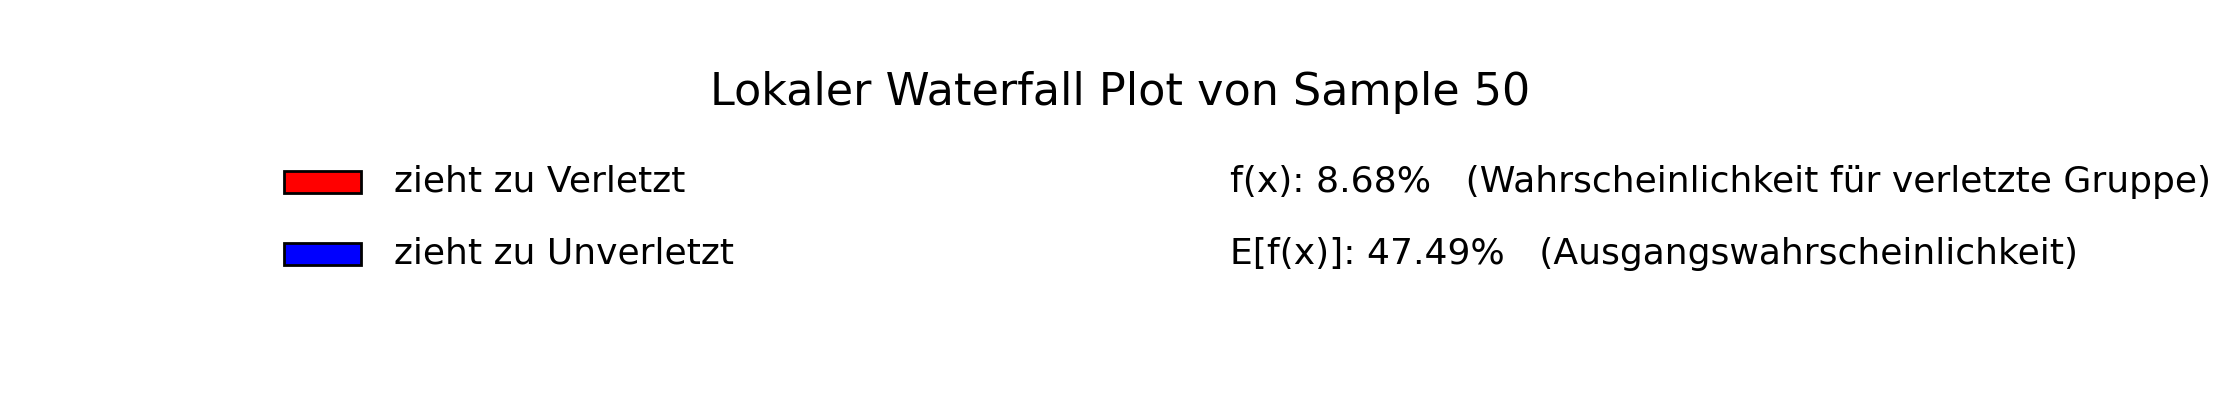

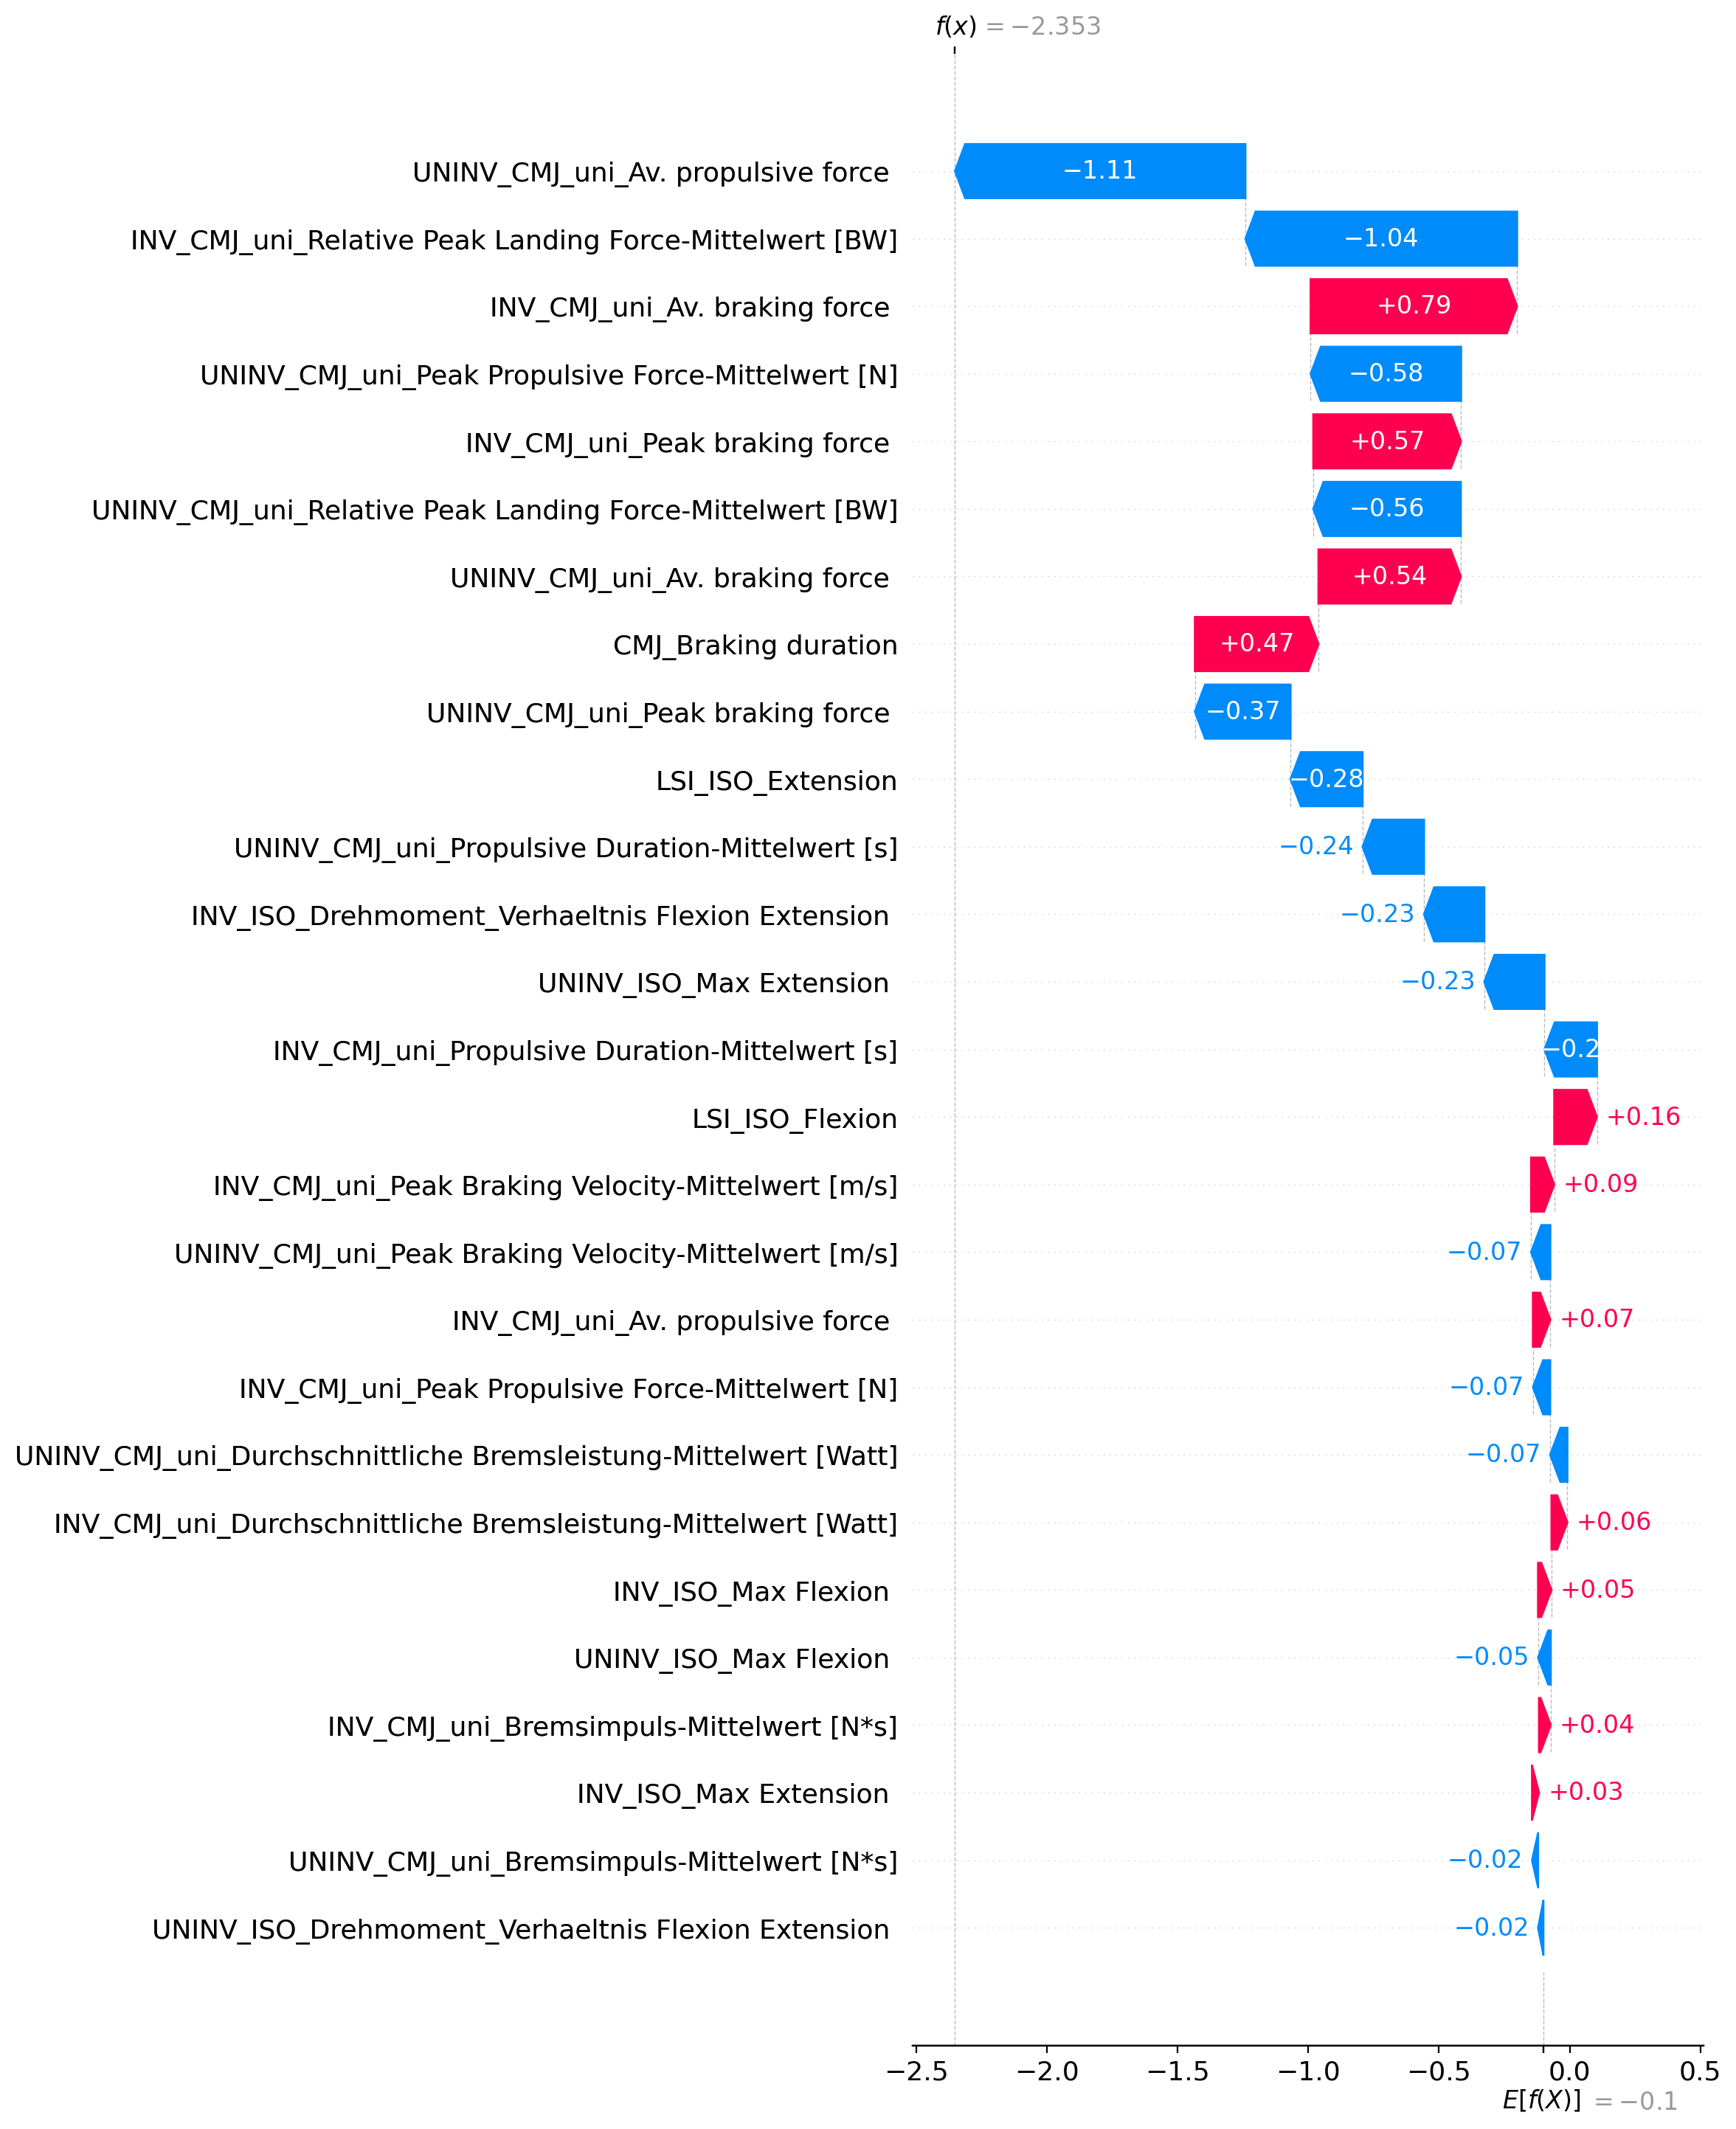

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.special import expit
import shap

def plot_local_waterfall_two_figures(
    features,
    shap_stack,
    exp_val,
    sample_idx=None,
    combine_zeros=True,          # True = SHAP=0-Features bündeln
    max_display=None,            # None = alle zeigen
    # Geometrie
    width=11.0,                  # identische Breite beider Bilder (inches)
    header_height=1.8,           # Bild A Höhe
    row_height=0.18,             # Höhe pro Zeile im Waterfall
    base_height=1.2,             # Grundhöhe Waterfall
    # Ränder Waterfall (für lange Namen etc.)
    left=0.30, right=0.97, top=0.98, bottom=0.08,
    dpi=200
):
    """
    Zeigt zwei Bilder:
      A) Header (Titel + Farbfelder + Wahrscheinlichkeiten, exakt zeilengleich)
      B) Klassischer SHAP-Waterfall (gleiche Breite)
    Es wird NICHT gespeichert – nur plt.show() in beiden Fällen.
    exp_val muss die Baseline der POSITIVEN Klasse (1) in Log-Odds sein.
    """
    # 1) Sample wählen
    if sample_idx is None:
        rng = np.random.default_rng(42)
        sample_idx = int(rng.integers(0, shap_stack.shape[0]))

    # 2) Werte & Namen
    vals_full  = shap_stack[sample_idx, :]
    names_full = list(features)

    if combine_zeros:
        nz = vals_full != 0
        vals = vals_full[nz].tolist()
        names = [names_full[i] for i in range(len(names_full)) if nz[i]]
        if (~nz).sum() > 0:
            names.append("Restliche Null-Features")
            vals.append(0.0)
    else:
        vals = vals_full.tolist()
        names = names_full

    # 3) Explanation bauen
    exp = shap.Explanation(
        values=np.array(vals),
        base_values=float(exp_val),
        feature_names=names
    )

    # 4) Wahrscheinlichkeiten (aus Log-Odds)
    fx_logit = exp.base_values + float(np.sum(exp.values))
    p_fx   = float(expit(fx_logit))
    p_base = float(expit(exp.base_values))

    # ---------- Bild A: Header ----------
    figA = plt.figure(figsize=(width, header_height), dpi=dpi)
    axA = figA.add_axes([0, 0, 1, 1])
    axA.axis("off")

    # Titel
    axA.text(0.5, 0.80, f"Lokaler Waterfall Plot von Sample {sample_idx}",
             ha="center", va="center", fontsize=16)

    # Gemeinsame Layout-Positionen (normierte Achskoordinaten 0..1)
    x_left_patch = 0.12      # Start der Farbfelder (links)
    x_left_text  = 0.17      # Text zu den Farbfeldern
    x_right_col  = 0.55      # Spalte für f(x) / E[f(x)] (rechts)
    y1, y2       = 0.55, 0.35  # Zeile 1 & 2 (linke und rechte Elemente teilen sich dieselbe y-Höhe)

    # Farbfeld-Größe
    box_w, box_h = 0.035, 0.06

    # Zeile 1: Rot + „zieht zu Verletzt“  |  f(x): …
    axA.add_patch(Rectangle((x_left_patch, y1 - box_h/2), box_w, box_h,
                            facecolor="red", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y1, "zieht zu Verletzt",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    axA.text(x_right_col, y1,
             f"f(x): {p_fx:,.2%}   (Wahrscheinlichkeit für verletzte Gruppe)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    # Zeile 2: Blau + „zieht zu Unverletzt“ | E[f(x)]: …
    axA.add_patch(Rectangle((x_left_patch, y2 - box_h/2), box_w, box_h,
                            facecolor="blue", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y2, "zieht zu Unverletzt",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    axA.text(x_right_col, y2,
             f"E[f(x)]: {p_base:,.2%}   (Ausgangswahrscheinlichkeit)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    plt.show()

    # ---------- Bild B: klassischer Waterfall ----------
    n_rows = len(exp.values) if max_display is None else min(max_display, len(exp.values))
    heightB = base_height + row_height * n_rows

    figB = plt.figure(figsize=(width, heightB), dpi=dpi)
    shap.plots.waterfall(
        exp,
        show=False,
        max_display=(len(exp.values) if max_display is None else max_display)
    )

    # Ränder feinjustieren, damit Labels nicht abgeschnitten werden
    plt.gcf().subplots_adjust(left=left, right=right, top=top, bottom=bottom)
    plt.show()

plot_local_waterfall_two_figures(
    features=features,
    shap_stack=shap_stack,
    exp_val=exp_val,
    sample_idx=50,          # oder None für zufällig
    combine_zeros=True,
    max_display=None,       # oder z. B. 30
    width=11.0, header_height=1.8, row_height=0.18, base_height=1.2,
    left=0.30, right=0.97, top=0.98, bottom=0.08, dpi=200
)


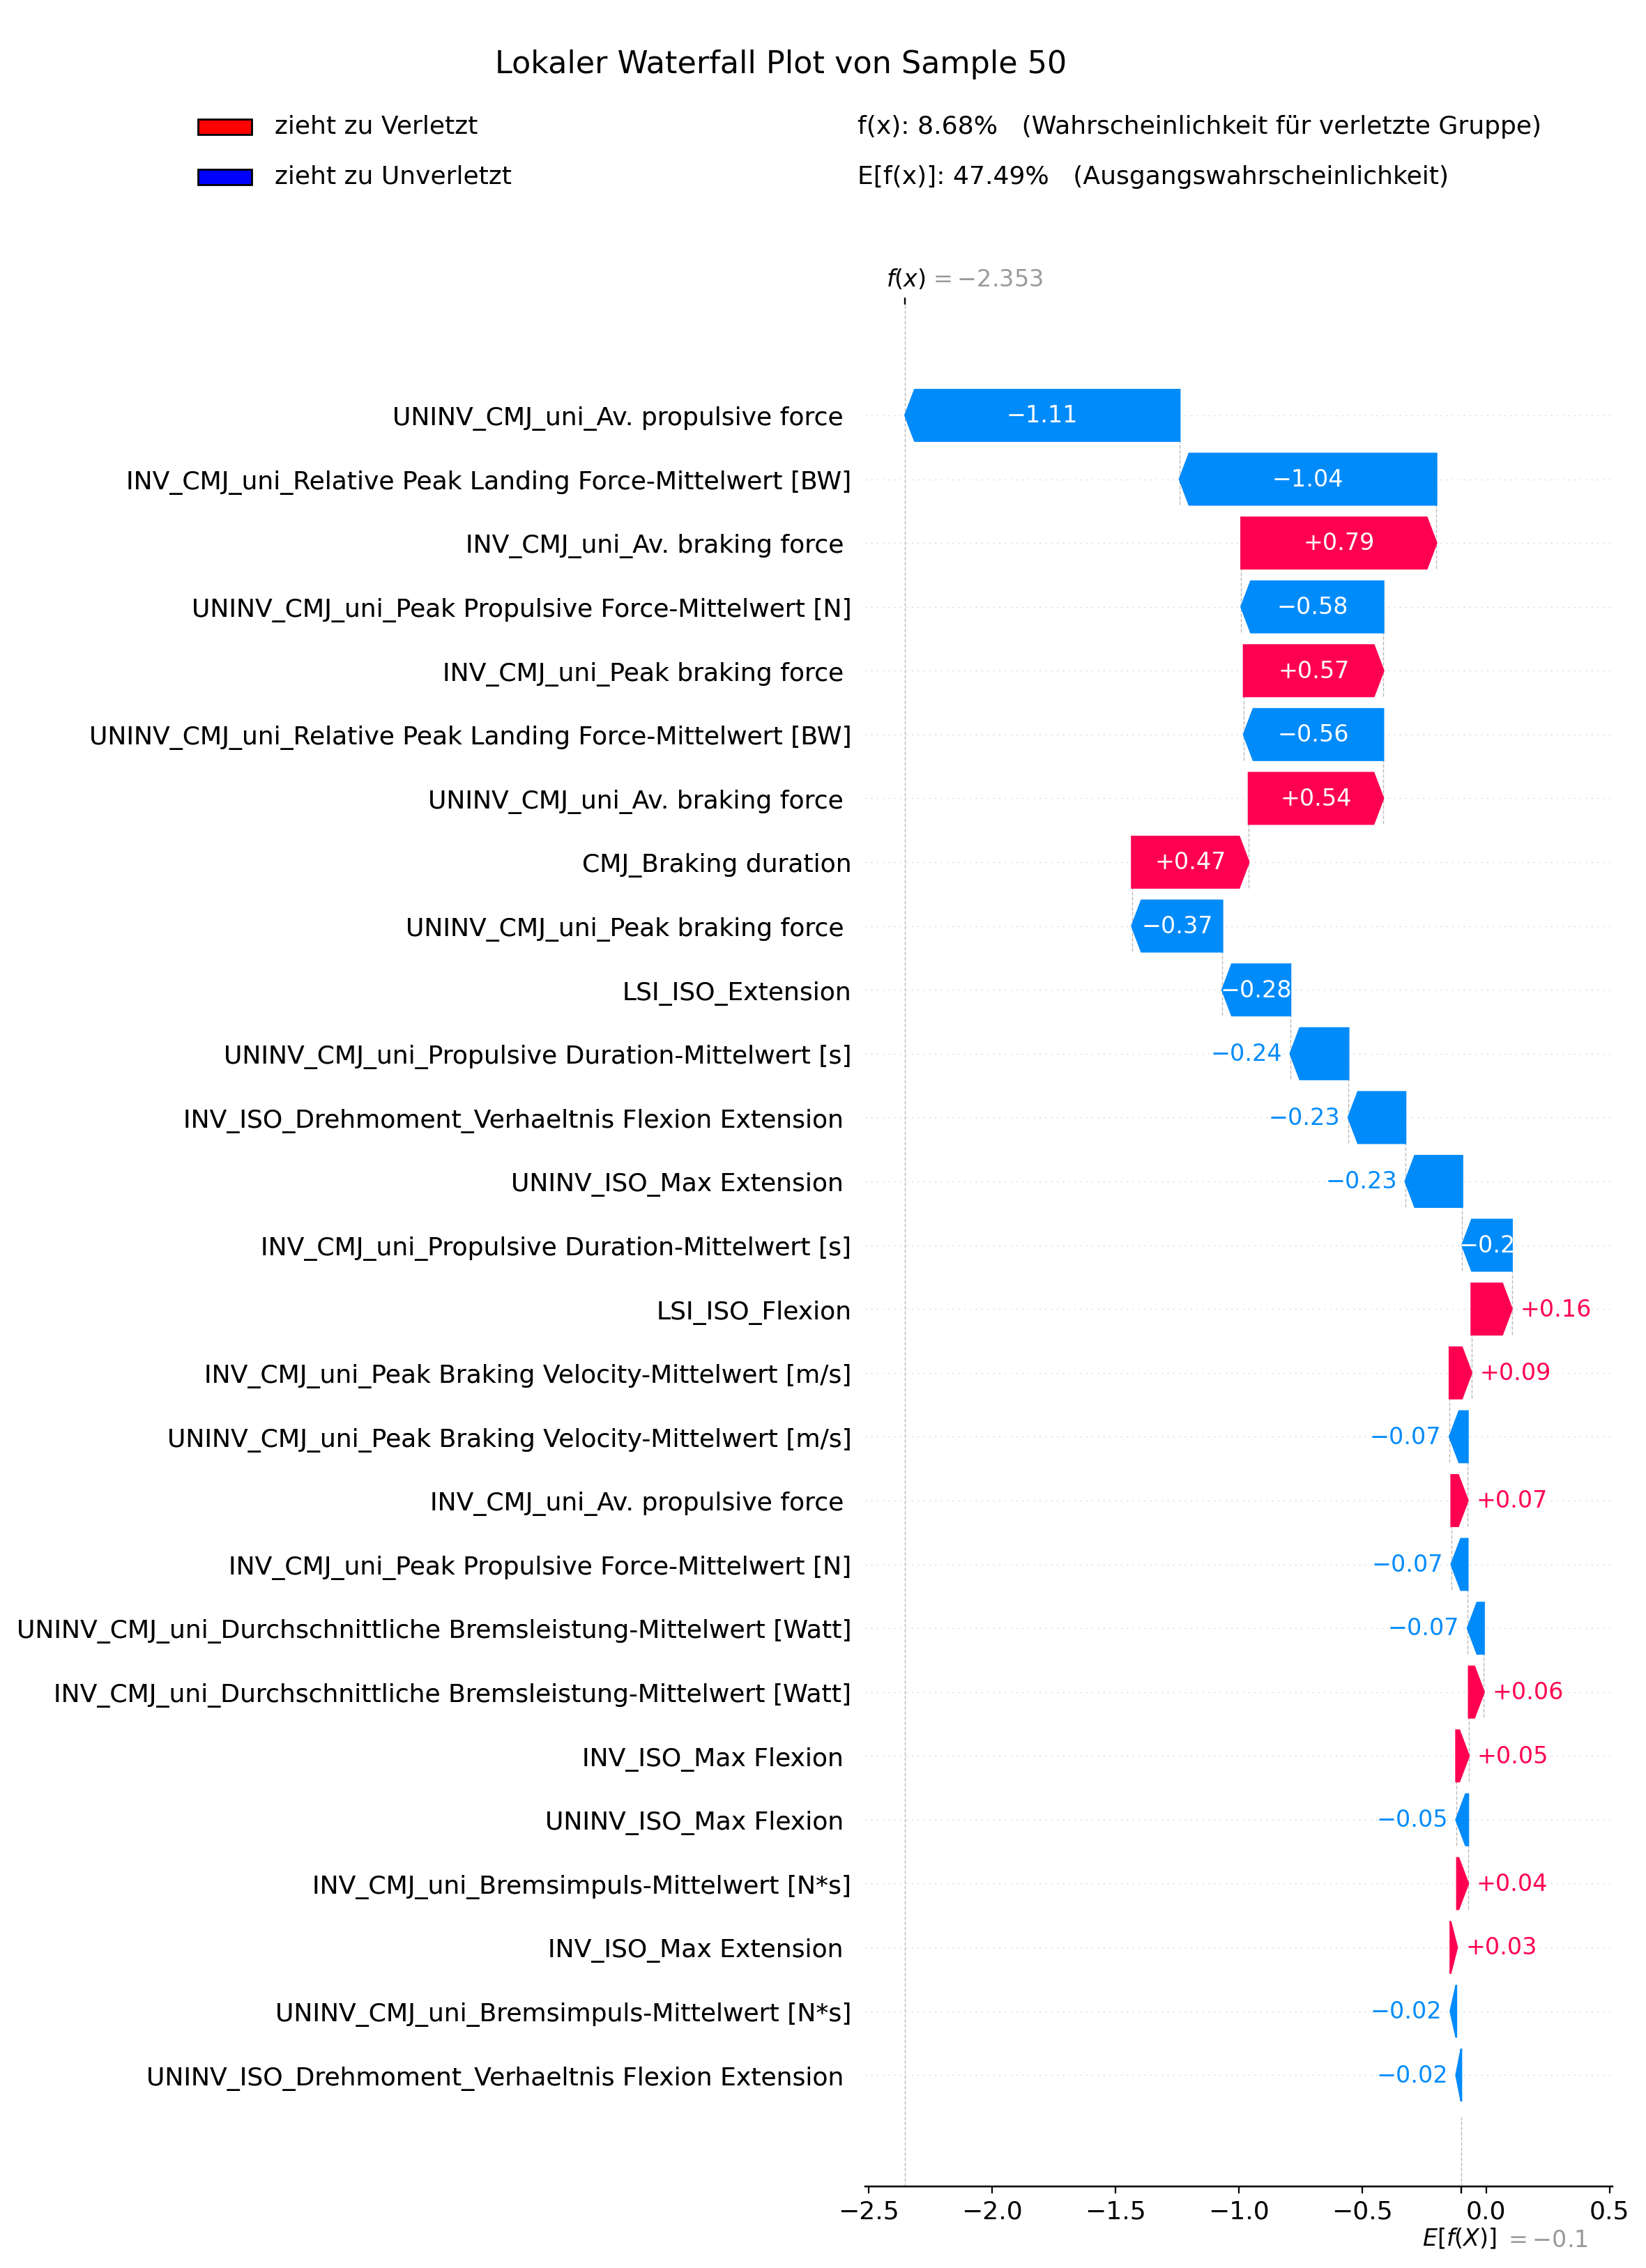

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.special import expit
from io import BytesIO
import tempfile, os
from PIL import Image
import shap

def plot_local_waterfall_combined_tempfiles(
    features,
    shap_stack,
    exp_val,
    sample_idx=None,
    combine_zeros=True,
    max_display=None,
    # Geometrie wie bei dir
    width=11.0, header_height=1.8, row_height=0.18, base_height=1.2,
    left=0.30, right=0.97, top=0.98, bottom=0.08,
    dpi=200,
    spacer_px=10
):
    # ----- Sample & Explanation vorbereiten (wie bei dir) -----
    if sample_idx is None:
        rng = np.random.default_rng(42)
        sample_idx = int(rng.integers(0, shap_stack.shape[0]))

    vals_full  = shap_stack[sample_idx, :]
    names_full = list(features)
    if combine_zeros:
        nz = vals_full != 0
        vals  = vals_full[nz].tolist()
        names = [names_full[i] for i in range(len(names_full)) if nz[i]]
        if (~nz).sum() > 0:
            names.append("Restliche Null-Features"); vals.append(0.0)
    else:
        vals, names = vals_full.tolist(), names_full

    exp = shap.Explanation(values=np.array(vals), base_values=float(exp_val), feature_names=names)

    fx_logit = exp.base_values + float(np.sum(exp.values))
    p_fx   = float(expit(fx_logit))
    p_base = float(expit(exp.base_values))

    # ===== 1) Header-Plot -> temporäre PNG (ohne tight) =====
    figA = plt.figure(figsize=(width, header_height), dpi=dpi)
    axA = figA.add_axes([0, 0, 1, 1]); axA.axis("off")

    axA.text(0.5, 0.80, f"Lokaler Waterfall Plot von Sample {sample_idx}",
             ha="center", va="center", fontsize=16)

    x_left_patch, x_left_text, x_right_col = 0.12, 0.17, 0.55
    y1, y2 = 0.55, 0.35
    box_w, box_h = 0.035, 0.06

    axA.add_patch(Rectangle((x_left_patch, y1 - box_h/2), box_w, box_h,
                            facecolor="red", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y1, "zieht zu Verletzt",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)
    axA.text(x_right_col, y1,
             f"f(x): {p_fx:,.2%}   (Wahrscheinlichkeit für verletzte Gruppe)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    axA.add_patch(Rectangle((x_left_patch, y2 - box_h/2), box_w, box_h,
                            facecolor="blue", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y2, "zieht zu Unverletzt",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)
    axA.text(x_right_col, y2,
             f"E[f(x)]: {p_base:,.2%}   (Ausgangswahrscheinlichkeit)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    tmpA = tempfile.NamedTemporaryFile(delete=False, suffix=".png"); tmpA.close()
    figA.savefig(tmpA.name, format="png", dpi=dpi, facecolor=figA.get_facecolor(),
                 bbox_inches=None, pad_inches=0)  # << keine 'tight'-Beschneidung
    plt.close(figA)

    # ===== 2) Waterfall-Plot -> temporäre PNG (ohne tight) =====
    n_rows = len(exp.values) if max_display is None else min(max_display, len(exp.values))
    heightB = base_height + row_height * n_rows

    figB = plt.figure(figsize=(width, heightB), dpi=dpi)
    shap.plots.waterfall(exp, show=False,
                         max_display=(len(exp.values) if max_display is None else max_display))
    # deine manuelle Randsetzung (damit nichts abgeschnitten wird)
    plt.gcf().subplots_adjust(left=left, right=right, top=top, bottom=bottom)

    tmpB = tempfile.NamedTemporaryFile(delete=False, suffix=".png"); tmpB.close()
    figB = plt.gcf()
    figB.canvas.draw()  # sicherstellen, dass Layout fertig ist
    figB.savefig(tmpB.name, format="png", dpi=dpi, facecolor=figB.get_facecolor(),
                bbox_inches="tight", pad_inches=0.02)  # << nimmt die vollen Label-Extents mit

    plt.close(plt.gcf())

    # ===== 3) Beide PNGs laden & exakt untereinander packen =====
    imgA = Image.open(tmpA.name).convert("RGBA")
    imgB = Image.open(tmpB.name).convert("RGBA")

    # optionaler weißer Spacer
    if spacer_px > 0:
        spacer = Image.new("RGBA", (max(imgA.width, imgB.width), spacer_px), (255, 255, 255, 255))
    else:
        spacer = None

    # gleiche Breite herstellen durch **weißes Padding** (keine Skalierung!)
    W = max(imgA.width, imgB.width)
    if imgA.width != W:
        pad = Image.new("RGBA", (W - imgA.width, imgA.height), (255, 255, 255, 255))
        imgA = Image.fromarray(np.hstack([np.array(imgA), np.array(pad)]))
    if imgB.width != W:
        pad = Image.new("RGBA", (W - imgB.width, imgB.height), (255, 255, 255, 255))
        imgB = Image.fromarray(np.hstack([np.array(imgB), np.array(pad)]))

    parts = [imgA]
    if spacer is not None: parts.append(spacer)
    parts.append(imgB)

    total_h = sum(p.height for p in parts)
    combo = Image.new("RGBA", (W, total_h), (255, 255, 255, 255))
    y = 0
    for p in parts:
        combo.paste(p, (0, y))
        y += p.height

    # ===== 4) Nur EIN Bild anzeigen (1:1 Pixel, kein Zoom) =====
    combo_np = np.asarray(combo)[..., :3]  # RGB
    h_px, w_px = combo_np.shape[:2]
    fig = plt.figure(figsize=(w_px / dpi, h_px / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis("off")
    ax.imshow(combo_np, interpolation="none")
    plt.show()

    # Temp-Dateien aufräumen
    try:
        os.remove(tmpA.name); os.remove(tmpB.name)
    except Exception:
        pass

plot_local_waterfall_combined_tempfiles(
    features=features,
    shap_stack=shap_stack,
    exp_val=exp_val,
    sample_idx=50,          # oder None
    combine_zeros=True,
    max_display=None,
    width=11.0, header_height=1.8, row_height=0.18, base_height=1.2,
    left=0.30, right=0.97, top=0.98, bottom=0.08,
    dpi=200, spacer_px=0
)
